# SIM SWAP ANALYSIS

In [1]:
import clickhouse_connect
import k
import pandas as pd
from datetime import datetime, timedelta, timezone

# Connect to ClickHouse with resource limits
client = clickhouse_connect.get_client(
    host='192.168.1.95',
    port=8123,
    username='default',
    password='',
    database='ceir_gold',
    settings={
        'max_execution_time': 120,
        'max_memory_usage': 2_000_000_000,  # 2GB max
        'max_threads': 2,
        'priority': 5
    }
)

# --------------------------------------------------------------------------------

def fetch_in_chunks(
    client,
    table: str,
    cols: list[str],
    days: int = 120,
    chunk_size: int = 300_000,
    max_rows: int | None = None,
    order_key: str = "changed_at",
    tie_key: str = "msisdn",
):
    """
    Keyset pagination: ORDER BY changed_at DESC, msisdn DESC
    Next chunk uses (changed_at < cursor_changed_at) OR (changed_at = cursor_changed_at AND msisdn < cursor_msisdn)
    """
    cutoff = datetime.now(timezone.utc) - timedelta(days=days)

    cursor_order = datetime.now(timezone.utc)
    cursor_tie = ""  # msisdn (string)

    parts: list[pd.DataFrame] = []
    total = 0

    # Always include order_key for cursor advancement
    select_cols = cols.copy()
    if order_key not in select_cols:
        select_cols.append(order_key)

    select_list = ",\n            ".join(select_cols)

    while True:
        cutoff_s = cutoff.strftime("%Y-%m-%d %H:%M:%S")
        cursor_s = cursor_order.strftime("%Y-%m-%d %H:%M:%S")

        q = f"""
        SELECT
            {select_list}
        FROM {table}
        WHERE {order_key} >= toDateTime('{cutoff_s}')
          AND (
                {order_key} < toDateTime('{cursor_s}')
                OR ({order_key} = toDateTime('{cursor_s}') AND {tie_key} < '{cursor_tie}')
              )
        ORDER BY {order_key} DESC, {tie_key} DESC
        LIMIT {chunk_size}
        """

        df = client.query_df(q)
        if df.empty:
            break

        total += len(df)

        # Keep only requested columns (drop cursor column if it wasn't requested)
        out = df[cols].copy()
        parts.append(out)

        # Advance cursor using last row of this chunk
        last = df.iloc[-1]
        cursor_order = pd.to_datetime(last[order_key], utc=True).to_pydatetime()
        cursor_tie = str(last[tie_key])

        print(f"{table}: fetched {len(df):,} (total {total:,}) cursor={cursor_order} / {cursor_tie}")

        if max_rows is not None and total >= max_rows:
            break

    return pd.concat(parts, ignore_index=True) if parts else pd.DataFrame(columns=cols)


# --------------------------------------------------------------------------------
# Fetch data from sim_swaps using the correct schema
df_swaps = fetch_in_chunks(
    client,
    table="sim_swaps",
    cols=[
        "msisdn",
        "old_imsi",
        "new_imsi",
        "imei",
        "device_type",
        "changed_at",
        "source",
    ],
    days=120,
    chunk_size=500_000,
    max_rows=50_000_000,
    order_key="changed_at",
    tie_key="msisdn",
)

print(df_swaps.head())
print("DONE. rows:", len(df_swaps))

sim_swaps: fetched 500,000 (total 500,000) cursor=2026-02-15 12:04:52+00:00 / 254731865989
sim_swaps: fetched 500,000 (total 1,000,000) cursor=2026-02-10 12:34:42+00:00 / 256751252729
sim_swaps: fetched 500,000 (total 1,500,000) cursor=2026-02-05 06:46:52+00:00 / 233505480646
sim_swaps: fetched 500,000 (total 2,000,000) cursor=2026-01-31 09:50:34+00:00 / 11837141775
sim_swaps: fetched 500,000 (total 2,500,000) cursor=2026-01-28 01:19:26+00:00 / 256790931244
sim_swaps: fetched 500,000 (total 3,000,000) cursor=2026-01-25 12:27:10+00:00 / 256743487365
sim_swaps: fetched 500,000 (total 3,500,000) cursor=2026-01-19 22:47:56+00:00 / 256787394622
sim_swaps: fetched 500,000 (total 4,000,000) cursor=2026-01-16 11:07:03+00:00 / 254762711691
sim_swaps: fetched 500,000 (total 4,500,000) cursor=2026-01-11 02:03:12+00:00 / 254102262422
sim_swaps: fetched 500,000 (total 5,000,000) cursor=2026-01-06 06:46:10+00:00 / 256754144778
sim_swaps: fetched 500,000 (total 5,500,000) cursor=2026-01-02 12:56:38+0

In [2]:
df_swaps.head()

,msisdn,old_imsi,new_imsi,imei,device_type,changed_at,source
0,254785356575,641010417498616,639035214500707,35472411475103,Smartphone,2026-02-20 07:00:17,roamer
1,254737684492,641010279712654,639035062328520,35858594525981,Smartphone,2026-02-20 07:00:16,roamer
2,915754120916240,641010401247651,404909244629091,86950106977131,Modem,2026-02-20 07:00:15,roamer
3,254733717868,641010400793764,639035324049366,35581728941018,Smartphone,2026-02-20 07:00:15,roamer
4,915754120916240,641010401247651,404909244629091,86950106977131,Modem,2026-02-20 07:00:09,roamer


#### Ofset Time from UTC to UTC+3 (Kampala Time)

In [3]:
# Ensure datetime
df_swaps["changed_at"] = pd.to_datetime(df_swaps["changed_at"], errors="coerce")

# Localize as UTC (since ClickHouse server is UTC)
df_swaps["changed_at"] = (
    df_swaps["changed_at"]
        .dt.tz_localize("UTC")
        .dt.tz_convert("Africa/Kampala")
)

In [4]:
df_swaps["changed_at"].dt.tz

zoneinfo.ZoneInfo(key='Africa/Kampala')

#### Enrich SIM Swap Data with Country of SIM Origin/ Registration - From IMSI

In [5]:
mcc_lu = pd.read_csv("/Users/wmuheki/Documents/Projects/Analytics/CEIR/clean_dumps/MCC_Each_country.csv", dtype=str)
mcc_lu.head()


,MCC,Country
0,289,Abkhazia
1,412,Afghanistan
2,276,Albania
3,603,Algeria
4,544,American Samoa


In [6]:
# --- 1) Load + normalize MCC lookup ---
mcc_lu = (
    pd.read_csv(
        "/Users/wmuheki/Documents/Projects/Analytics/CEIR/clean_dumps/MCC_Each_country.csv",
        dtype=str
    )
    .rename(columns={"MCC": "mcc", "Country": "country"})
)

mcc_lu["mcc"] = mcc_lu["mcc"].astype("string").str.strip().str.zfill(3)
mcc_lu["country"] = mcc_lu["country"].astype("string").str.strip()

# keep first occurrence if duplicates exist
mcc_lu = mcc_lu.drop_duplicates(subset=["mcc"], keep="first")

mcc_to_country = mcc_lu.set_index("mcc")["country"]  # Series for fast map()


# --- 2) Helper: extract MCC from IMSI ---
def imsi_to_mcc(s: pd.Series) -> pd.Series:
    s = s.astype("string")
    # keep digits only, then take first 3 digits
    mcc = s.str.replace(r"\D+", "", regex=True).str.slice(0, 3)
    # normalize to 3 digits where possible
    return mcc.where(mcc.str.len().eq(3), pd.NA)

# --- 3) Enrich df_swaps with old/new country ---
df_swaps = df_swaps.copy()

df_swaps["old_mcc"] = imsi_to_mcc(df_swaps["old_imsi"])
df_swaps["new_mcc"] = imsi_to_mcc(df_swaps["new_imsi"])

df_swaps["old_country"] = df_swaps["old_mcc"].map(mcc_to_country).fillna("UNKNOWN")
df_swaps["new_country"] = df_swaps["new_mcc"].map(mcc_to_country).fillna("UNKNOWN")

# (optional) keep only key fields for inspection
df_swaps[[
    "msisdn", "old_imsi", "old_mcc", "old_country",
    "new_imsi", "new_mcc", "new_country",
    "imei", "device_type", "changed_at", "source"
]].head()

,msisdn,old_imsi,old_mcc,old_country,new_imsi,new_mcc,new_country,imei,device_type,changed_at,source
0,254785356575,641010417498616,641,Uganda,639035214500707,639,Kenya,35472411475103,Smartphone,2026-02-20 10:00:17+03:00,roamer
1,254737684492,641010279712654,641,Uganda,639035062328520,639,Kenya,35858594525981,Smartphone,2026-02-20 10:00:16+03:00,roamer
2,915754120916240,641010401247651,641,Uganda,404909244629091,404,India,86950106977131,Modem,2026-02-20 10:00:15+03:00,roamer
3,254733717868,641010400793764,641,Uganda,639035324049366,639,Kenya,35581728941018,Smartphone,2026-02-20 10:00:15+03:00,roamer
4,915754120916240,641010401247651,641,Uganda,404909244629091,404,India,86950106977131,Modem,2026-02-20 10:00:09+03:00,roamer


In [7]:
df_swaps.drop(columns=["old_mcc", "new_mcc"], errors="ignore", inplace=True)

In [8]:
df_swaps.head()

,msisdn,old_imsi,new_imsi,imei,device_type,changed_at,source,old_country,new_country
0,254785356575,641010417498616,639035214500707,35472411475103,Smartphone,2026-02-20 10:00:17+03:00,roamer,Uganda,Kenya
1,254737684492,641010279712654,639035062328520,35858594525981,Smartphone,2026-02-20 10:00:16+03:00,roamer,Uganda,Kenya
2,915754120916240,641010401247651,404909244629091,86950106977131,Modem,2026-02-20 10:00:15+03:00,roamer,Uganda,India
3,254733717868,641010400793764,639035324049366,35581728941018,Smartphone,2026-02-20 10:00:15+03:00,roamer,Uganda,Kenya
4,915754120916240,641010401247651,404909244629091,86950106977131,Modem,2026-02-20 10:00:09+03:00,roamer,Uganda,India


#### Categorise by MNO

In [9]:
# --- 1) Define IMSI → MNO prefix map ---
IMSI_MNO_MAP = {
    "64110": "MTN",
    "64101": "AIRTEL",
    "64122": "AIRTEL",
    "64120": "HAMILTON",
    "64108": "TALKIO",
    "64114": "AFRICELL",
    "64104": "ORANGE",
}

# --- 2) Helper function ---
def imsi_to_mno(s: pd.Series) -> pd.Series:
    s = s.astype("string")
    prefix = (
        s.str.replace(r"\D+", "", regex=True)  # keep digits only
         .str.slice(0, 5)
    )
    return prefix.map(IMSI_MNO_MAP).fillna("UNKNOWN")


# --- 3) Apply to swaps dataset ---
df_swaps = df_swaps.copy()

df_swaps["old_mno"] = imsi_to_mno(df_swaps["old_imsi"])
df_swaps["new_mno"] = imsi_to_mno(df_swaps["new_imsi"])

In [10]:
df_swaps.head()

,msisdn,old_imsi,new_imsi,imei,device_type,changed_at,source,old_country,new_country,old_mno,new_mno
0,254785356575,641010417498616,639035214500707,35472411475103,Smartphone,2026-02-20 10:00:17+03:00,roamer,Uganda,Kenya,AIRTEL,UNKNOWN
1,254737684492,641010279712654,639035062328520,35858594525981,Smartphone,2026-02-20 10:00:16+03:00,roamer,Uganda,Kenya,AIRTEL,UNKNOWN
2,915754120916240,641010401247651,404909244629091,86950106977131,Modem,2026-02-20 10:00:15+03:00,roamer,Uganda,India,AIRTEL,UNKNOWN
3,254733717868,641010400793764,639035324049366,35581728941018,Smartphone,2026-02-20 10:00:15+03:00,roamer,Uganda,Kenya,AIRTEL,UNKNOWN
4,915754120916240,641010401247651,404909244629091,86950106977131,Modem,2026-02-20 10:00:09+03:00,roamer,Uganda,India,AIRTEL,UNKNOWN


In [11]:
target_mnos = ["AIRTEL"]

airtel_swaps = df_swaps[
    df_swaps["old_mno"].isin(target_mnos) |
    df_swaps["new_mno"].isin(target_mnos)
].copy()

# cleanup for safe matching
airtel_swaps["source"] = airtel_swaps["source"].astype(str).str.strip().str.lower()

airtel_roamers = airtel_swaps[airtel_swaps["source"] == "roamer"].copy()
airtel_domestic = airtel_swaps[airtel_swaps["source"] == "domestic"].copy()

print("Airtel swaps:", len(airtel_swaps))
print("Airtel roamers:", len(airtel_roamers))
print("Airtel domestic:", len(airtel_domestic))


Airtel swaps: 7469771
Airtel roamers: 3829688
Airtel domestic: 3640083


### Summary

In [12]:
def print_summary(data, segment_name):
    print("=" * 70)
    print(f"AIRTEL SIM SWAP – ANALYTICS SUMMARY ({segment_name.upper()})")
    print("=" * 70)

    total_swaps = len(data)
    unique_msisdn = data["msisdn"].nunique() if "msisdn" in data.columns else 0
    unique_imei = data["imei"].nunique() if "imei" in data.columns else 0

    print(f"Total Swap Events = {total_swaps:,}")
    print(f"Unique MSISDNs = {unique_msisdn:,}")
    print(f"Unique IMEIs = {unique_imei:,}")

    if total_swaps == 0:
        print("No records in this segment.")
        print("=" * 70)
        return

    print("\n" + "-" * 70)
    print("SOURCE DISTRIBUTION")

    source_counts = data["source"].value_counts(dropna=False) if "source" in data.columns else {}
    for k, v in source_counts.items():
        pct = (v / total_swaps) * 100
        print(f"{k} = {v:,} ({pct:.2f}%)")

    print("\n" + "-" * 70)
    print("MSISDN SWAP FREQUENCY")

    swap_per_msisdn = data["msisdn"].value_counts()
    single = (swap_per_msisdn == 1).sum()
    multi = (swap_per_msisdn > 1).sum()
    multi_5 = (swap_per_msisdn > 5).sum()
    multi_10 = (swap_per_msisdn > 10).sum()

    print(f"MSISDNs with 1 Swap = {single:,}")
    print(f"MSISDNs with >1 Swap = {multi:,}")
    print(f"MSISDNs with >5 Swaps = {multi_5:,}")
    print(f"MSISDNs with >10 Swaps = {multi_10:,}")

    print("\n" + "-" * 70)
    print("IMEI SHARING ANALYSIS")

    imei_users = data.groupby("imei")["msisdn"].nunique()
    imei_single = (imei_users == 1).sum()
    imei_multi = (imei_users > 1).sum()
    imei_10 = (imei_users > 10).sum()

    print(f"IMEIs used by 1 MSISDN = {imei_single:,}")
    print(f"IMEIs used by >1 MSISDN = {imei_multi:,}")
    print(f"IMEIs used by >10 MSISDNs = {imei_10:,}")

    if {"old_country", "new_country"}.issubset(data.columns):
        print("\n" + "-" * 70)
        print("COUNTRY TRANSITIONS")

        country_changed = (data["old_country"] != data["new_country"]).sum()
        pct_country_changed = (country_changed / total_swaps) * 100

        print(f"Swaps with Country Change = {country_changed:,} ({pct_country_changed:.2f}%)")

        top_dest = data["new_country"].value_counts().head(5)
        print("\nTop Destination Countries:")
        for c, v in top_dest.items():
            print(f"{c} = {v:,}")

    if {"old_mno", "new_mno"}.issubset(data.columns):
        print("\n" + "-" * 70)
        print("MNO TRANSITIONS")

        mno_changed = (data["old_mno"] != data["new_mno"]).sum()
        pct_mno_changed = (mno_changed / total_swaps) * 100

        print(f"Swaps with MNO Change = {mno_changed:,} ({pct_mno_changed:.2f}%)")

        top_mno_dest = data["new_mno"].value_counts().head(5)
        print("\nTop New MNOs:")
        for m, v in top_mno_dest.items():
            print(f"{m} = {v:,}")

    if "minutes_between" in data.columns:
        print("\n" + "-" * 70)
        print("VELOCITY ANALYSIS")

        fast_1h = (data["minutes_between"] <= 60).sum()
        fast_24h = (data["minutes_between"] <= 1440).sum()

        print(f"Swaps within 1 Hour = {fast_1h:,}")
        print(f"Swaps within 24 Hours = {fast_24h:,}")

    print("\n" + "-" * 70)
    print("DEVICE TYPE DISTRIBUTION")

    if "device_type" in data.columns:
        device_counts = data["device_type"].value_counts().head(5)
        for d, v in device_counts.items():
            pct = (v / total_swaps) * 100
            print(f"{d} = {v:,} ({pct:.2f}%)")

    print("=" * 70)


# Run 3 reports: Combined vs Roamers vs Domestic
print_summary(airtel_swaps, "Combined")
print_summary(airtel_roamers, "Roamers")
print_summary(airtel_domestic, "Domestic")


AIRTEL SIM SWAP – ANALYTICS SUMMARY (COMBINED)
Total Swap Events = 7,469,771
Unique MSISDNs = 871,239
Unique IMEIs = 1,170,474

----------------------------------------------------------------------
SOURCE DISTRIBUTION
roamer = 3,829,688 (51.27%)
domestic = 3,640,083 (48.73%)

----------------------------------------------------------------------
MSISDN SWAP FREQUENCY
MSISDNs with 1 Swap = 317,802
MSISDNs with >1 Swap = 553,437
MSISDNs with >5 Swaps = 162,757
MSISDNs with >10 Swaps = 68,560

----------------------------------------------------------------------
IMEI SHARING ANALYSIS
IMEIs used by 1 MSISDN = 1,122,485
IMEIs used by >1 MSISDN = 47,989
IMEIs used by >10 MSISDNs = 196

----------------------------------------------------------------------
COUNTRY TRANSITIONS
Swaps with Country Change = 3,829,688 (51.27%)

Top Destination Countries:
Uganda = 3,640,083
Kenya = 1,867,909
Democratic Republic of Congo = 499,203
Netherlands = 277,999
Belgium = 201,095

--------------------------

### Frequency & Velocity Anomalies Analysis

In [13]:

# Ensure datetime is parsed first
airtel_roamers["changed_at"] = pd.to_datetime(airtel_roamers["changed_at"], errors="coerce")
airtel_domestic["changed_at"] = pd.to_datetime(airtel_domestic["changed_at"], errors="coerce")

# 1) High Swap Frequency per MSISDN
# ------------------------------------------------
roamer_swap_counts = (
    airtel_roamers
    .groupby("msisdn")
    .size()
    .reset_index(name="swap_count")
    .sort_values("swap_count", ascending=False)
)

domestic_swap_counts = (
    airtel_domestic
    .groupby("msisdn")
    .size()
    .reset_index(name="swap_count")
    .sort_values("swap_count", ascending=False)
)

# 2) Rapid Consecutive Swaps
# ------------------------------------------------
airtel_roamers = airtel_roamers.sort_values(["msisdn", "changed_at"]).copy()
airtel_roamers["prev_swap"] = airtel_roamers.groupby("msisdn")["changed_at"].shift()
airtel_roamers["minutes_between"] = (
    (airtel_roamers["changed_at"] - airtel_roamers["prev_swap"]).dt.total_seconds() / 60
)

airtel_domestic = airtel_domestic.sort_values(["msisdn", "changed_at"]).copy()
airtel_domestic["prev_swap"] = airtel_domestic.groupby("msisdn")["changed_at"].shift()
airtel_domestic["minutes_between"] = (
    (airtel_domestic["changed_at"] - airtel_domestic["prev_swap"]).dt.total_seconds() / 60
)

### Cross-Border Swap Risk Analysis

In [14]:
# 1) Country Change Detection (separate)
# ------------------------------------------------
airtel_roamers["country_changed"] = (
    airtel_roamers["old_country"] != airtel_roamers["new_country"]
)

airtel_domestic["country_changed"] = (
    airtel_domestic["old_country"] != airtel_domestic["new_country"]
)

# 2) Domestic IMSI -> Foreign IMSI (separate)
# ------------------------------------------------
airtel_roamers["foreign_swap"] = (
    (airtel_roamers["old_country"] == "Uganda") &
    (airtel_roamers["new_country"] != "Uganda")
)

airtel_domestic["foreign_swap"] = (
    (airtel_domestic["old_country"] == "Uganda") &
    (airtel_domestic["new_country"] != "Uganda")
)

### Time-of-Day Risk Profiling

In [15]:
airtel_roamers["hour"] = airtel_roamers["changed_at"].dt.hour
airtel_roamers["weekday"] = airtel_roamers["changed_at"].dt.day_name()

airtel_domestic["hour"] = airtel_domestic["changed_at"].dt.hour
airtel_domestic["weekday"] = airtel_domestic["changed_at"].dt.day_name()


In [16]:
# Roamers
df_roamers = airtel_roamers.copy()
df_roamers["changed_at"] = pd.to_datetime(df_roamers["changed_at"], errors="coerce")
df_roamers = df_roamers.sort_values(["msisdn", "changed_at"])
df_roamers["hour"] = df_roamers["changed_at"].dt.hour
df_roamers["date"] = df_roamers["changed_at"].dt.date
df_roamers["weekday"] = df_roamers["changed_at"].dt.day_name()

# Domestic
df_domestic = airtel_domestic.copy()
df_domestic["changed_at"] = pd.to_datetime(df_domestic["changed_at"], errors="coerce")
df_domestic = df_domestic.sort_values(["msisdn", "changed_at"])
df_domestic["hour"] = df_domestic["changed_at"].dt.hour
df_domestic["date"] = df_domestic["changed_at"].dt.date
df_domestic["weekday"] = df_domestic["changed_at"].dt.day_name()


In [17]:
# Preview
df_roamers.head(5)

,msisdn,old_imsi,new_imsi,imei,device_type,changed_at,source,old_country,new_country,old_mno,new_mno,prev_swap,minutes_between,country_changed,foreign_swap,hour,weekday,date
3424391,11831613475,641010417545598,204043898152877,86560004992253,Modem,2026-01-20 16:14:12+03:00,roamer,Uganda,Netherlands,AIRTEL,UNKNOWN,NaT,NaN,True,True,16,Tuesday,2026-01-20
3378425,11831613475,641010417545598,204043898152877,86560004992253,Modem,2026-01-21 04:13:13+03:00,roamer,Uganda,Netherlands,AIRTEL,UNKNOWN,2026-01-20 16:14:12+03:00,719.016667,True,True,4,Wednesday,2026-01-21
3247139,11831613475,641010417545598,204043898152877,86560004992253,Modem,2026-01-23 04:16:40+03:00,roamer,Uganda,Netherlands,AIRTEL,UNKNOWN,2026-01-21 04:13:13+03:00,2883.450000,True,True,4,Friday,2026-01-23
2023955,11831613475,641010417545598,204043898152877,86560004992253,Modem,2026-01-31 07:12:21+03:00,roamer,Uganda,Netherlands,AIRTEL,UNKNOWN,2026-01-23 04:16:40+03:00,11695.683333,True,True,7,Saturday,2026-01-31
1504741,11831613475,641010417545598,204043898152877,86560004992253,Modem,2026-02-05 07:13:31+03:00,roamer,Uganda,Netherlands,AIRTEL,UNKNOWN,2026-01-31 07:12:21+03:00,7201.166667,True,True,7,Thursday,2026-02-05


In [18]:
df_domestic.head(5)

,msisdn,old_imsi,new_imsi,imei,device_type,changed_at,source,old_country,new_country,old_mno,new_mno,prev_swap,minutes_between,country_changed,foreign_swap,hour,weekday,date
6824200,11832176985,641010406880053,641010423543452,35016603413288,Mobile Phone/Feature phone,2025-12-22 12:53:09+03:00,domestic,Uganda,Uganda,AIRTEL,AIRTEL,NaT,NaN,False,False,12,Monday,2025-12-22
4353080,11832176985,641010423543452,641010404370979,35993048195156,Mobile Phone/Feature phone,2026-01-12 22:31:41+03:00,domestic,Uganda,Uganda,AIRTEL,AIRTEL,2025-12-22 12:53:09+03:00,30818.533333,False,False,22,Monday,2026-01-12
10186082,11832177003,641010257768876,641010416755478,35074048096462,Mobile Phone/Feature phone,2025-11-16 22:13:19+03:00,domestic,Uganda,Uganda,AIRTEL,AIRTEL,NaT,NaN,False,False,22,Sunday,2025-11-16
8481990,11832389314,641010412792423,641010271687954,35486411108029,Mobile Phone/Feature phone,2025-12-01 12:38:47+03:00,domestic,Uganda,Uganda,AIRTEL,AIRTEL,NaT,NaN,False,False,12,Monday,2025-12-01
997132,11832389350,641010242316744,641010417223987,35694514137397,Mobile Phone/Feature phone,2026-02-10 16:15:59+03:00,domestic,Uganda,Uganda,AIRTEL,AIRTEL,NaT,NaN,False,False,16,Tuesday,2026-02-10


### Swaps over time (daily time series)

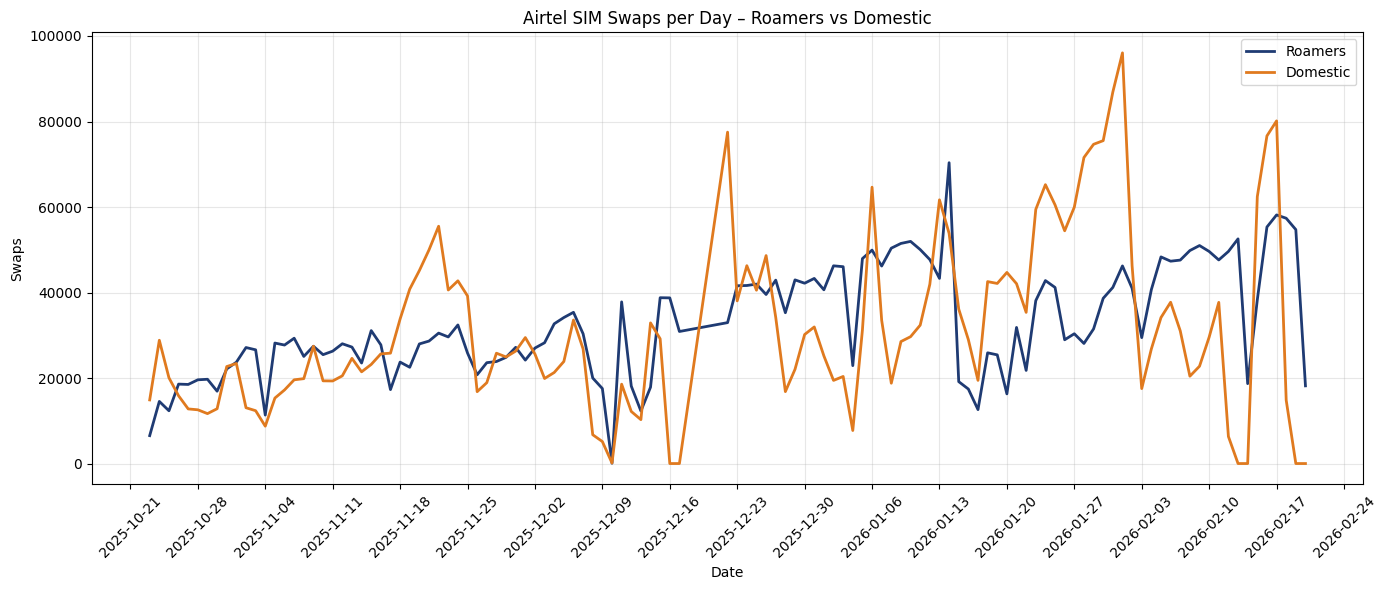

In [19]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Daily counts
daily_roamers = df_roamers.groupby("date").size()
daily_domestic = df_domestic.groupby("date").size()

# Align dates (ensures both series share same index)
daily = (
    daily_roamers.rename("roamers")
    .to_frame()
    .join(daily_domestic.rename("domestic"), how="outer")
    .fillna(0)
    .sort_index()
)

# Single plot
plt.figure(figsize=(14, 6))

plt.plot(
    daily.index,
    daily["roamers"],
    color="#1f3b73",
    linewidth=2,
    label="Roamers"
)

plt.plot(
    daily.index,
    daily["domestic"],
    color="#e07a1f",
    linewidth=2,
    label="Domestic"
)

plt.title("Airtel SIM Swaps per Day – Roamers vs Domestic")
plt.xlabel("Date")
plt.ylabel("Swaps")
plt.grid(True, alpha=0.3)

plt.gca().xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
plt.xticks(rotation=45)

plt.legend()
plt.tight_layout()
plt.show()

### Swaps by hour of day

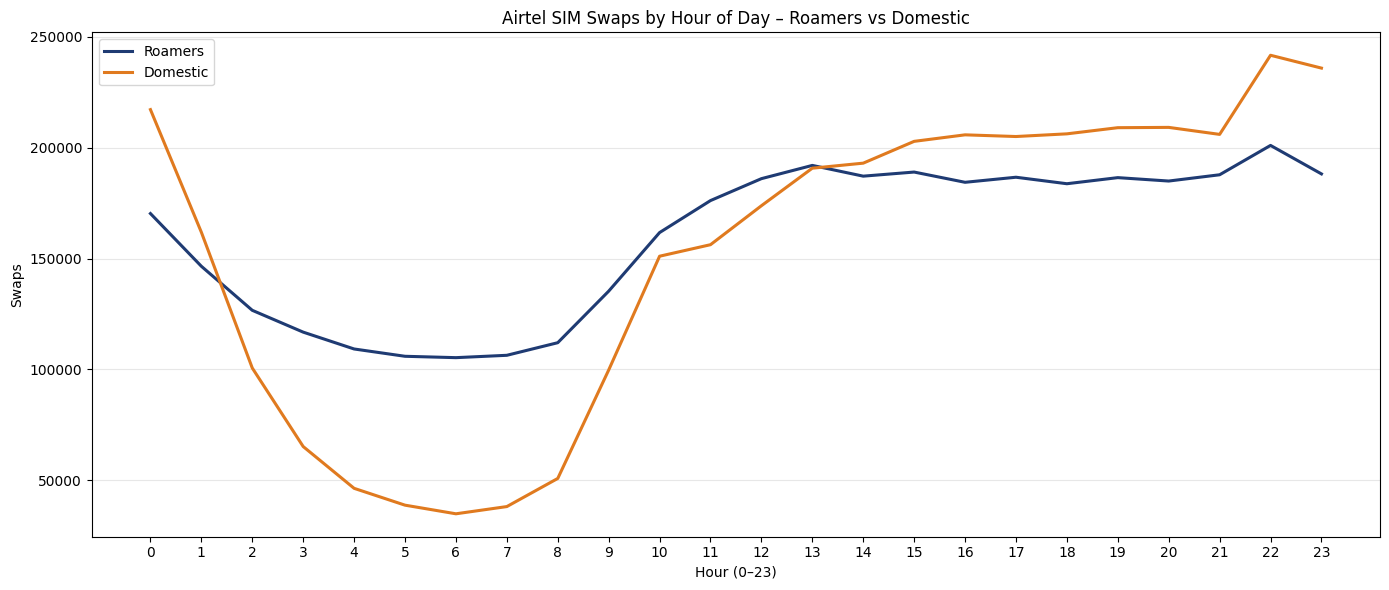

In [20]:
import matplotlib.pyplot as plt
import numpy as np

# Count by hour
hourly_roamers = df_roamers["hour"].value_counts().sort_index()
hourly_domestic = df_domestic["hour"].value_counts().sort_index()

# Ensure all 24 hours exist
hours = np.arange(24)

hourly = (
    hourly_roamers.rename("roamers")
    .to_frame()
    .join(hourly_domestic.rename("domestic"), how="outer")
    .reindex(hours, fill_value=0)
)

# Plot
plt.figure(figsize=(14, 6))

plt.plot(
    hourly.index,
    hourly["roamers"],
    linewidth=2.2,
    color="#1f3b73",     # Navy
    label="Roamers"
)

plt.plot(
    hourly.index,
    hourly["domestic"],
    linewidth=2.2,
    color="#e07a1f",     # Orange
    label="Domestic"
)

plt.title("Airtel SIM Swaps by Hour of Day – Roamers vs Domestic")
plt.xlabel("Hour (0–23)")
plt.ylabel("Swaps")
plt.xticks(hours)
plt.grid(True, axis="y", alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

In [21]:
hourly_domestic.head(24)

hour
0     217180
1     161858
2     100616
3      65199
4      46354
5      38759
6      34867
7      38127
8      50812
9      99698
10    151049
11    156247
12    173815
13    190757
14    193026
15    202860
16    205798
17    205039
18    206247
19    209023
20    209159
21    206001
22    241692
23    235900
Name: count, dtype: int64

In [22]:
hourly_roamers.head(24)

hour
0     170297
1     146514
2     126646
3     116807
4     109209
5     105913
6     105296
7     106358
8     112040
9     135282
10    161714
11    176146
12    186033
13    192009
14    187162
15    189011
16    184391
17    186674
18    183746
19    186494
20    184958
21    187787
22    201025
23    188176
Name: count, dtype: int64

### Swaps by weekday

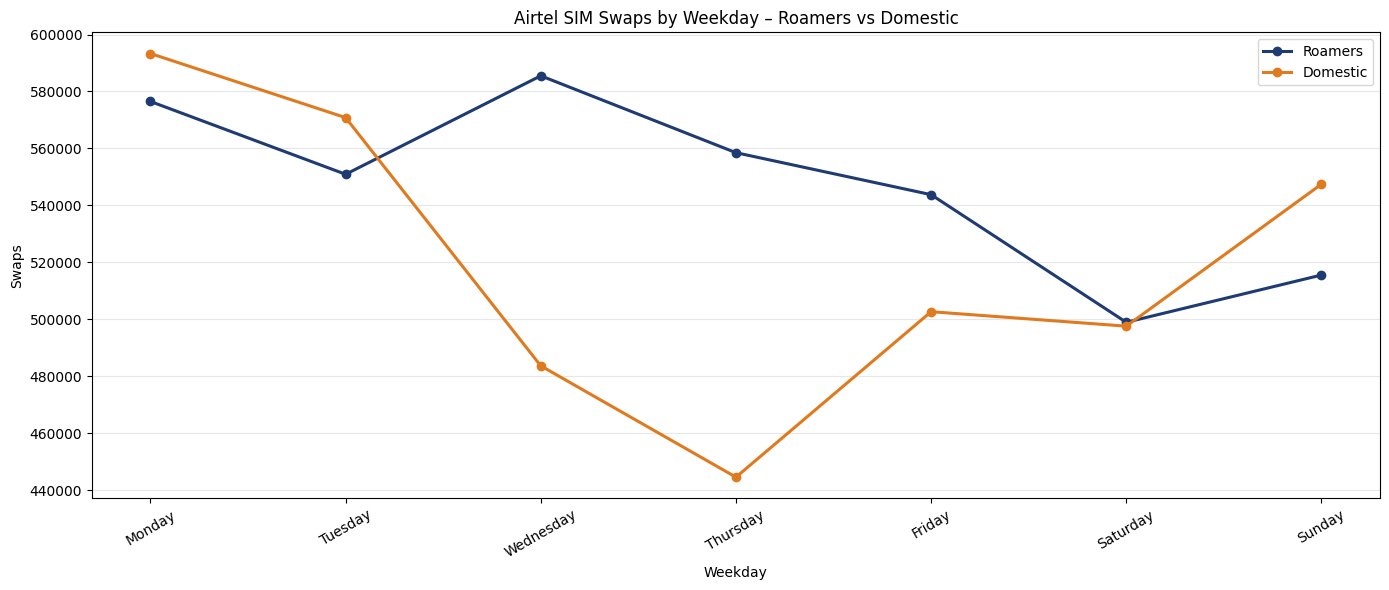

In [23]:
import matplotlib.pyplot as plt
import pandas as pd

order = ["Monday", "Tuesday", "Wednesday",
         "Thursday", "Friday", "Saturday", "Sunday"]

# Ensure correct weekday ordering
wk_roamers = (
    df_roamers["weekday"]
    .value_counts()
    .reindex(order)
    .fillna(0)
)

wk_domestic = (
    df_domestic["weekday"]
    .value_counts()
    .reindex(order)
    .fillna(0)
)

# Combine
weekly = pd.DataFrame({
    "Roamers": wk_roamers,
    "Domestic": wk_domestic
})

# Plot
plt.figure(figsize=(14, 6))

plt.plot(
    weekly.index,
    weekly["Roamers"],
    linewidth=2.2,
    color="#1f3b73",   # Navy
    marker="o",
    label="Roamers"
)

plt.plot(
    weekly.index,
    weekly["Domestic"],
    linewidth=2.2,
    color="#e07a1f",   # Orange
    marker="o",
    label="Domestic"
)

plt.title("Airtel SIM Swaps by Weekday – Roamers vs Domestic")
plt.xlabel("Weekday")
plt.ylabel("Swaps")
plt.xticks(rotation=30)
plt.grid(True, axis="y", alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

In [24]:
wk_domestic.head(10)

weekday
Monday       593331
Tuesday      570820
Wednesday    483658
Thursday     444566
Friday       502669
Saturday     497586
Sunday       547453
Name: count, dtype: int64

In [25]:
wk_roamers.head(10)

weekday
Monday       576492
Tuesday      550920
Wednesday    585505
Thursday     558511
Friday       543763
Saturday     498950
Sunday       515547
Name: count, dtype: int64

### Velocity distribution

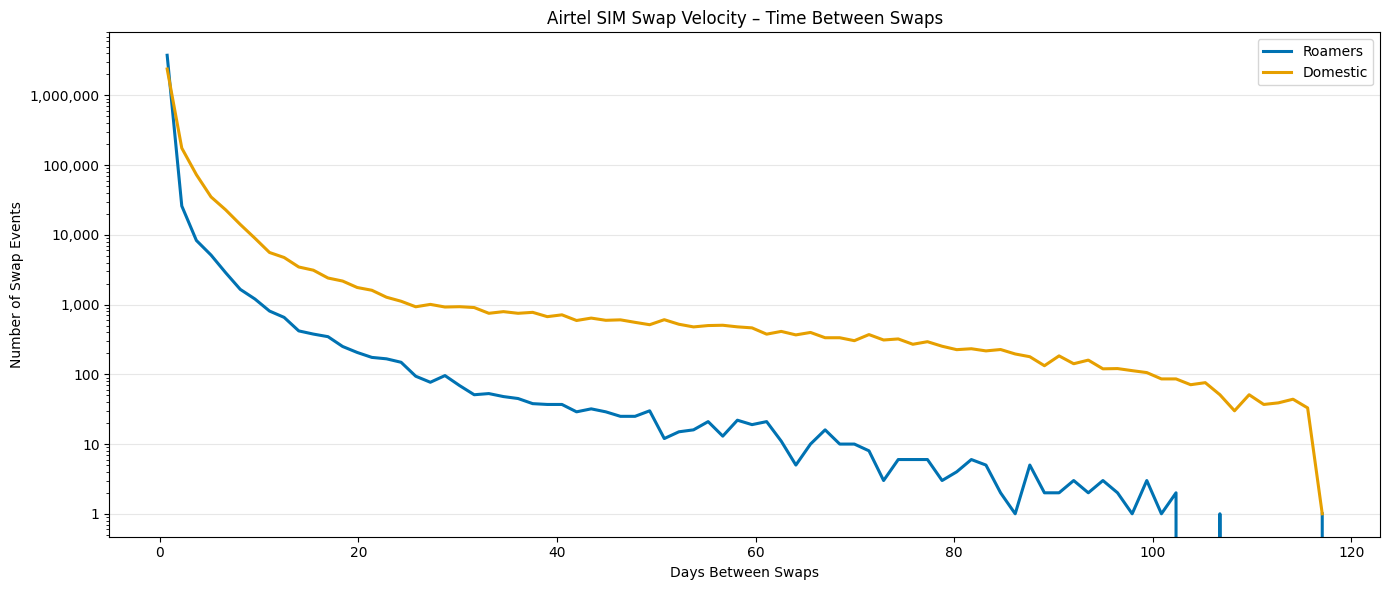

In [26]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import FuncFormatter

# Convert minutes → days
x_roamers = df_roamers["minutes_between"].dropna() / 1440
x_domestic = df_domestic["minutes_between"].dropna() / 1440

# Create shared bins
bins = 80
counts_r, edges = np.histogram(x_roamers, bins=bins)
counts_d, _ = np.histogram(x_domestic, bins=edges)

# Midpoints for line plotting
centers = (edges[:-1] + edges[1:]) / 2

plt.figure(figsize=(14, 6))
plt.style.use("default")

plt.plot(
    centers,
    counts_r,
    linewidth=2.2,
    color="#0072B2",   # Blue
    label="Roamers"
)

plt.plot(
    centers,
    counts_d,
    linewidth=2.2,
    color="#E69F00",   # Orange
    label="Domestic"
)

plt.title("Airtel SIM Swap Velocity – Time Between Swaps")
plt.xlabel("Days Between Swaps")
plt.ylabel("Number of Swap Events")

plt.yscale("log")
plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f"{int(x):,}")
)

plt.grid(True, axis="y", alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

In [27]:
import pandas as pd
import numpy as np

# Use original minutes (NOT divided by 1440)
r = df_roamers["minutes_between"].dropna()
d = df_domestic["minutes_between"].dropna()

bin_size = 5

# Create bins based on global max to keep both aligned
max_val = int(
    np.ceil(max(r.max(), d.max()) / bin_size) * bin_size
)

bins = np.arange(0, max_val + bin_size, bin_size)

# Bucket
r_bucket = pd.cut(r, bins=bins, right=False)
d_bucket = pd.cut(d, bins=bins, right=False)

# Count
tab_r = r_bucket.value_counts().sort_index()
tab_d = d_bucket.value_counts().sort_index()

# Combine
velocity_table = pd.DataFrame({
    "minutes_bucket": tab_r.index.astype(str),
    "roamers": tab_r.values,
    "domestic": tab_d.values
})

velocity_table.head(100)

,minutes_bucket,roamers,domestic
0,"[0, 5)",1788956,785167
1,"[5, 10)",243581,165001
2,"[10, 15)",765650,104580
3,"[15, 20)",126302,65321
4,"[20, 25)",93303,50345
...,...,...,...
95,"[475, 480)",1097,2908
96,"[480, 485)",1190,3433
97,"[485, 490)",1067,2770
98,"[490, 495)",1086,2692


### Top MSISDNs by swap count

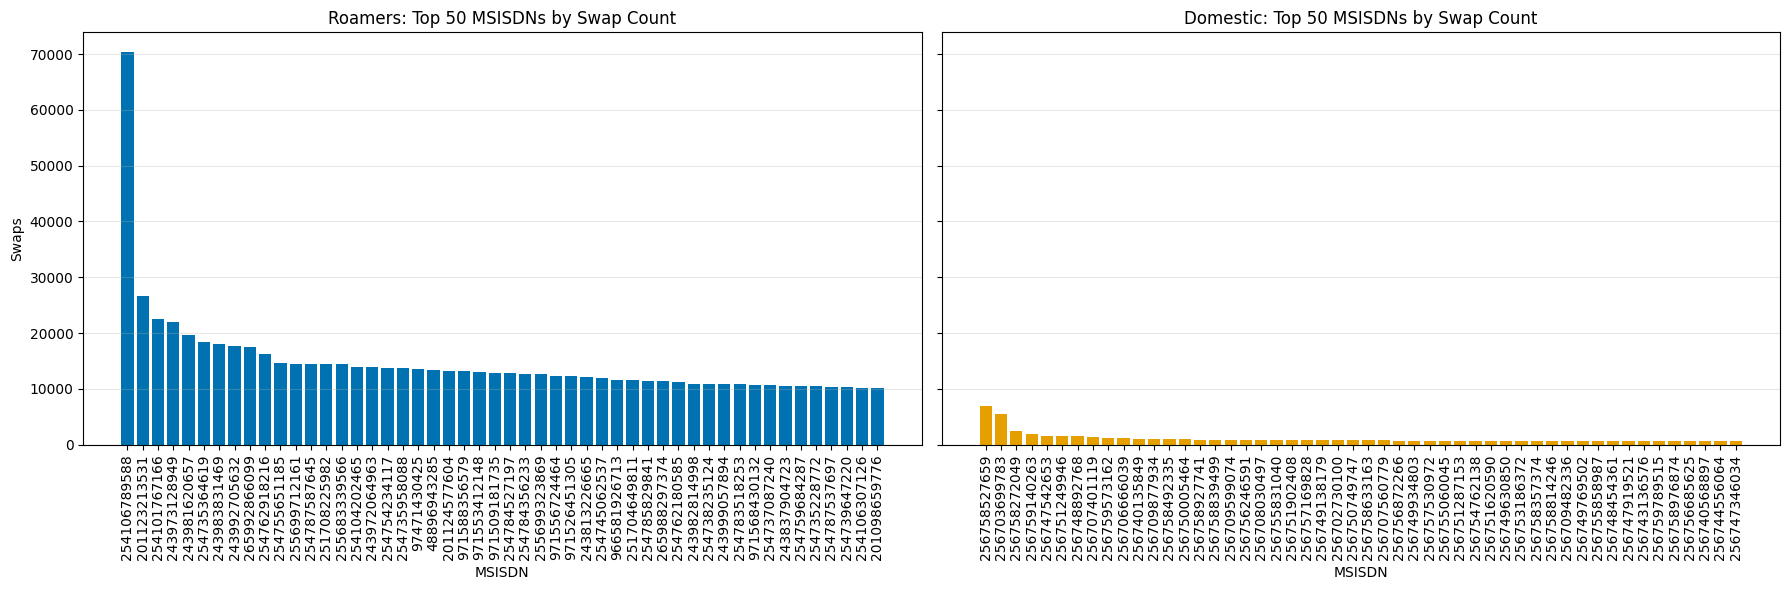

In [28]:
top_n = 50

msisdn_counts_roamers = (
    df_roamers.groupby("msisdn")
    .size()
    .sort_values(ascending=False)
    .head(top_n)
)

msisdn_counts_domestic = (
    df_domestic.groupby("msisdn")
    .size()
    .sort_values(ascending=False)
    .head(top_n)
)

fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=True)

# Roamers
axes[0].bar(
    msisdn_counts_roamers.index.astype(str),
    msisdn_counts_roamers.values,
    color="#0072B2"
)
axes[0].set_title(f"Roamers: Top {top_n} MSISDNs by Swap Count")
axes[0].set_xlabel("MSISDN")
axes[0].set_ylabel("Swaps")
axes[0].tick_params(axis="x", rotation=90)
axes[0].grid(True, axis="y", alpha=0.3)

# Domestic
axes[1].bar(
    msisdn_counts_domestic.index.astype(str),
    msisdn_counts_domestic.values,
    color="#E69F00"
)
axes[1].set_title(f"Domestic: Top {top_n} MSISDNs by Swap Count")
axes[1].set_xlabel("MSISDN")
axes[1].tick_params(axis="x", rotation=90)
axes[1].grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [29]:
msisdn_counts_domestic = (
    df_domestic.groupby("msisdn")
    .size()
    .sort_values(ascending=False)
    .head(top_n)
    .reset_index(name="swap_count")
)

# Add rank column
msisdn_counts_domestic.insert(0, "rank", range(1, len(msisdn_counts_domestic) + 1))

print("\nDOMESTIC – TOP MSISDNs BY SWAP COUNT")
print("="*50)
msisdn_counts_domestic


DOMESTIC – TOP MSISDNs BY SWAP COUNT


,rank,msisdn,swap_count
0,1,256758527659,6982
1,2,256703699783,5516
2,3,256758272049,2537
3,4,256759140263,2006
4,5,256747542653,1596
5,6,256751249946,1572
6,7,256748892768,1525
7,8,256707401119,1311
8,9,256759573162,1259
9,10,256706666039,1126


In [30]:
top_n = 50  # or whatever you used

msisdn_counts_roamers = (
    df_roamers.groupby("msisdn")
    .size()
    .sort_values(ascending=False)
    .head(top_n)
    .reset_index(name="swap_count")
)

# Add rank column (matches graph order)
msisdn_counts_roamers.insert(0, "rank", range(1, len(msisdn_counts_roamers) + 1))

print("\nROAMERS – TOP MSISDNs BY SWAP COUNT")
print("="*50)
msisdn_counts_roamers


ROAMERS – TOP MSISDNs BY SWAP COUNT


,rank,msisdn,swap_count
0,1,254106789588,70378
1,2,201123213531,26670
2,3,254101767166,22544
3,4,243973128949,22051
4,5,243981620657,19736
5,6,254735364619,18481
6,7,243983831469,18124
7,8,243992705632,17688
8,9,265992866099,17539
9,10,254762918216,16254


### Top IMEIs used in swaps

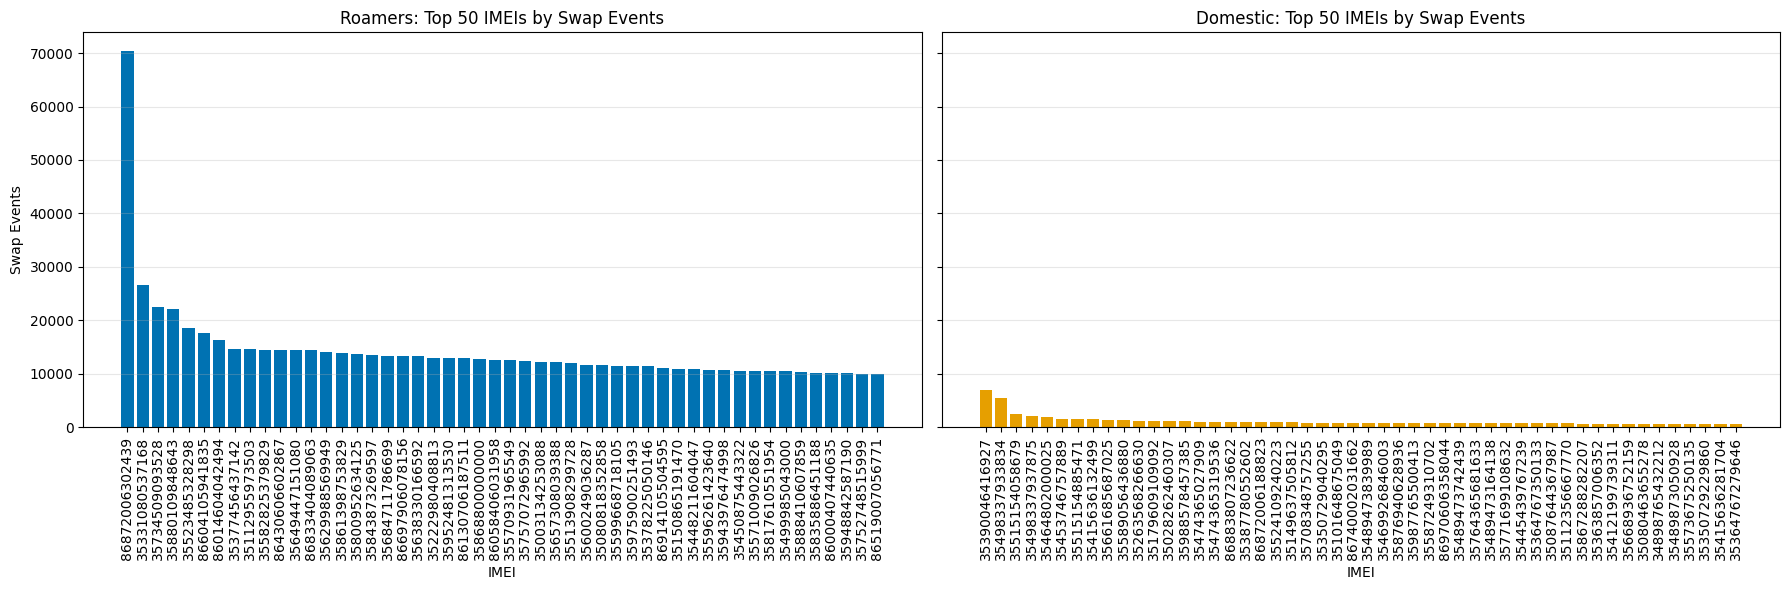

In [31]:
import matplotlib.pyplot as plt

top_n = 50

imei_counts_roamers = (
    df_roamers.groupby("imei")
    .size()
    .sort_values(ascending=False)
    .head(top_n)
)

imei_counts_domestic = (
    df_domestic.groupby("imei")
    .size()
    .sort_values(ascending=False)
    .head(top_n)
)

fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=True)

# Roamers
axes[0].bar(
    imei_counts_roamers.index.astype(str),
    imei_counts_roamers.values,
    color="#0072B2"
)
axes[0].set_title(f"Roamers: Top {top_n} IMEIs by Swap Events")
axes[0].set_xlabel("IMEI")
axes[0].set_ylabel("Swap Events")
axes[0].tick_params(axis="x", rotation=90)
axes[0].grid(True, axis="y", alpha=0.3)

# Domestic
axes[1].bar(
    imei_counts_domestic.index.astype(str),
    imei_counts_domestic.values,
    color="#E69F00"
)
axes[1].set_title(f"Domestic: Top {top_n} IMEIs by Swap Events")
axes[1].set_xlabel("IMEI")
axes[1].tick_params(axis="x", rotation=90)
axes[1].grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [32]:
tab_imei_domestic = (
    imei_counts_domestic
    .reset_index(name="swap_events")
)

tab_imei_domestic.insert(0, "rank", range(1, len(tab_imei_domestic) + 1))

print("\nDOMESTIC – TOP IMEIs BY SWAP EVENTS")
print("="*50)
tab_imei_domestic


DOMESTIC – TOP IMEIs BY SWAP EVENTS


,rank,imei,swap_events
0,1,35390046416927,6982
1,2,35498337933834,5515
2,3,35515154058679,2537
3,4,35498337937875,2005
4,5,35464802000025,1897
5,6,35453746757889,1595
6,7,35515154885471,1571
7,8,35415636132499,1525
8,9,35661685687025,1265
9,10,35589056436880,1259


In [33]:
tab_imei_roamers = (
    imei_counts_roamers
    .reset_index(name="swap_events")
)

tab_imei_roamers.insert(0, "rank", range(1, len(tab_imei_roamers) + 1))

print("\nROAMERS – TOP IMEIs BY SWAP EVENTS")
print("="*50)
tab_imei_roamers


ROAMERS – TOP IMEIs BY SWAP EVENTS


,rank,imei,swap_events
0,1,86872006302439,70373
1,2,35331080537168,26670
2,3,35734509093528,22542
3,4,35880109848643,22046
4,5,35523485328298,18481
5,6,86604105941835,17688
6,7,86014604042494,16254
7,8,35377456437142,14684
8,9,35112955973503,14621
9,10,35582825379829,14462


### IMEI → number of unique MSISDNs (bar)

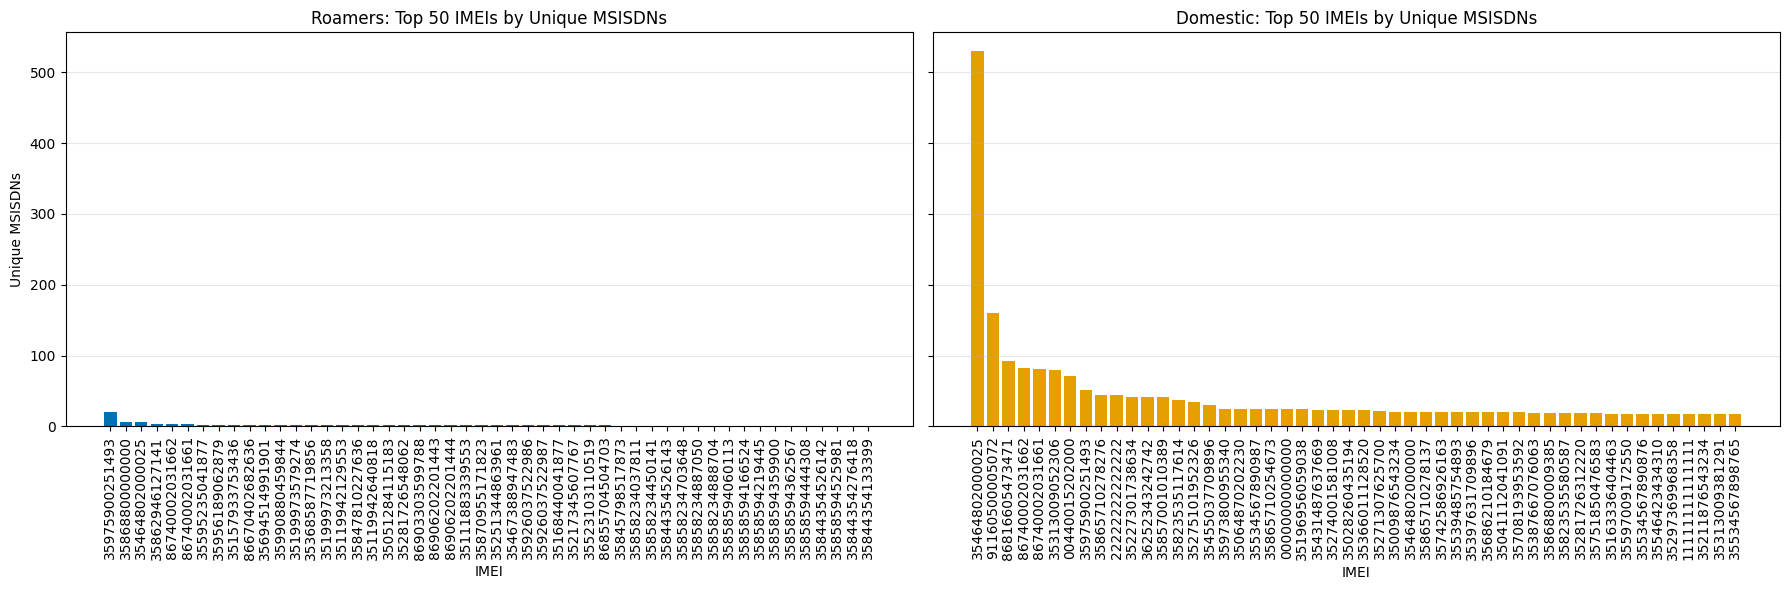

In [34]:
import matplotlib.pyplot as plt

top_n = 50

imei_msisdn_roamers = (
    df_roamers.groupby("imei")["msisdn"]
    .nunique()
    .sort_values(ascending=False)
    .head(top_n)
)

imei_msisdn_domestic = (
    df_domestic.groupby("imei")["msisdn"]
    .nunique()
    .sort_values(ascending=False)
    .head(top_n)
)

fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=True)

# Roamers
axes[0].bar(
    imei_msisdn_roamers.index.astype(str),
    imei_msisdn_roamers.values,
    color="#0072B2"
)
axes[0].set_title(f"Roamers: Top {top_n} IMEIs by Unique MSISDNs")
axes[0].set_xlabel("IMEI")
axes[0].set_ylabel("Unique MSISDNs")
axes[0].tick_params(axis="x", rotation=90)
axes[0].grid(True, axis="y", alpha=0.3)

# Domestic
axes[1].bar(
    imei_msisdn_domestic.index.astype(str),
    imei_msisdn_domestic.values,
    color="#E69F00"
)
axes[1].set_title(f"Domestic: Top {top_n} IMEIs by Unique MSISDNs")
axes[1].set_xlabel("IMEI")
axes[1].tick_params(axis="x", rotation=90)
axes[1].grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [35]:
tab_imei_domestic = (
    imei_msisdn_domestic
    .reset_index(name="unique_msisdns")
)

tab_imei_domestic.insert(0, "rank", range(1, len(tab_imei_domestic) + 1))

print("\nDOMESTIC – TOP IMEIs BY UNIQUE MSISDNs")
print("="*50)
tab_imei_domestic


DOMESTIC – TOP IMEIs BY UNIQUE MSISDNs


,rank,imei,unique_msisdns
0,1,35464802000025,530
1,2,91160500005072,160
2,3,86816605473471,92
3,4,86740002031662,82
4,5,86740002031661,81
5,6,35313009052306,80
6,7,00440015202000,71
7,8,35975900251493,51
8,9,35865710278276,45
9,10,22222222222222,44


In [36]:
tab_imei_roamers = (
    imei_msisdn_roamers
    .reset_index(name="unique_msisdns")
)

tab_imei_roamers.insert(0, "rank", range(1, len(tab_imei_roamers) + 1))

print("\nROAMERS – TOP IMEIs BY UNIQUE MSISDNs")
print("="*50)
tab_imei_roamers


ROAMERS – TOP IMEIs BY UNIQUE MSISDNs


,rank,imei,unique_msisdns
0,1,35975900251493,20
1,2,35868800000000,7
2,3,35464802000025,6
3,4,35862946127141,4
4,5,86740002031662,3
5,6,86740002031661,3
6,7,35595235041877,2
7,8,35956189062879,2
8,9,35157933753436,2
9,10,86670402682636,2


###  New country destinations

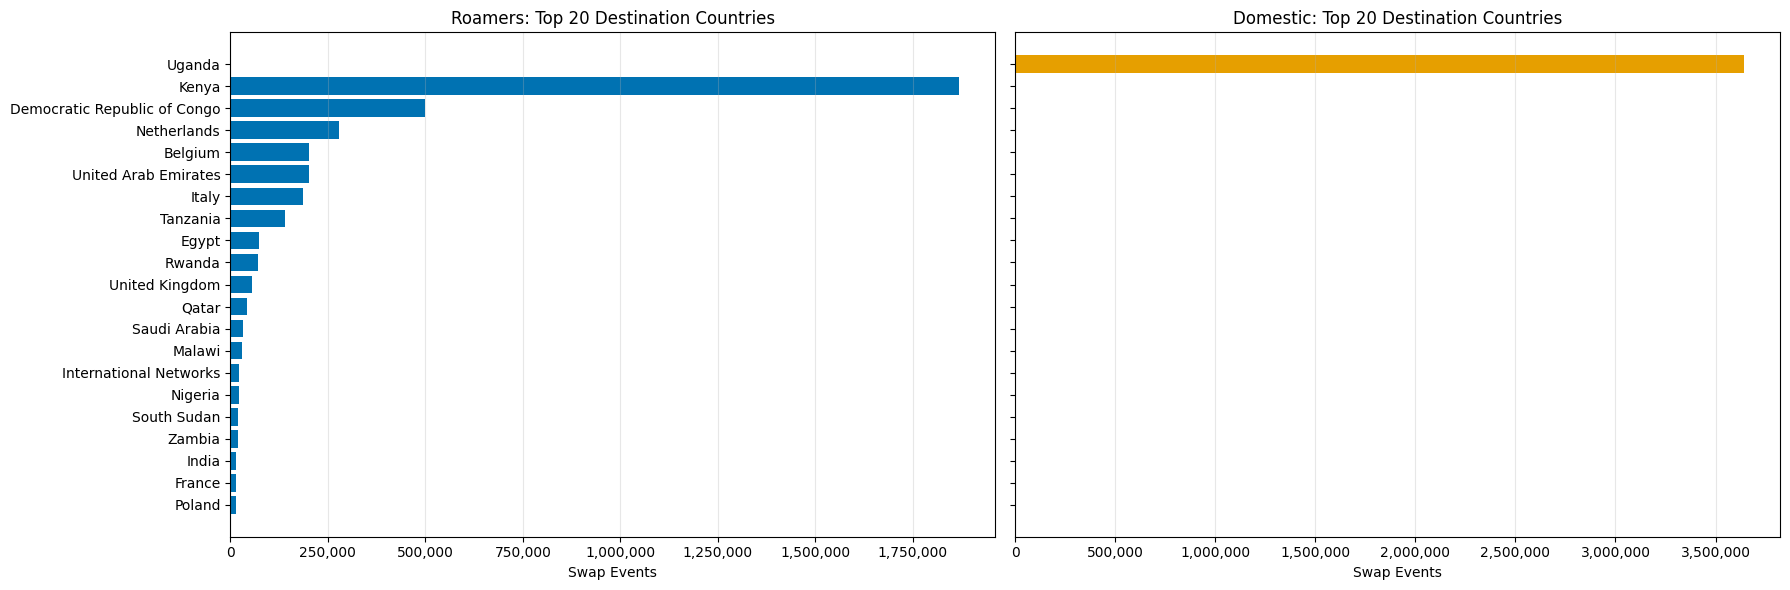

In [44]:
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter

top_n = 20

dest_roamers = (
    df_roamers["new_country"]
    .fillna("UNKNOWN")
    .value_counts()
    .head(top_n)
    .sort_values()
)

dest_domestic = (
    df_domestic["new_country"]
    .fillna("UNKNOWN")
    .value_counts()
    .head(top_n)
    .sort_values()
)

fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=True)

# Roamers
axes[0].barh(
    dest_roamers.index,
    dest_roamers.values,
    color="#0072B2"
)
axes[0].set_title(f"Roamers: Top {top_n} Destination Countries")
axes[0].set_xlabel("Swap Events")
axes[0].grid(True, axis="x", alpha=0.3)
axes[0].xaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))

# Domestic
axes[1].barh(
    dest_domestic.index,
    dest_domestic.values,
    color="#E69F00"
)
axes[1].set_title(f"Domestic: Top {top_n} Destination Countries")
axes[1].set_xlabel("Swap Events")
axes[1].grid(True, axis="x", alpha=0.3)
axes[1].xaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))

plt.tight_layout()
plt.show()

In [45]:
tab_dest_domestic = (
    df_domestic["new_country"]
    .fillna("UNKNOWN")
    .value_counts()
    .head(top_n)
    .reset_index()
)

tab_dest_domestic.columns = ["new_country", "swap_events"]
tab_dest_domestic.insert(0, "rank", range(1, len(tab_dest_domestic) + 1))

print("\nDOMESTIC – TOP DESTINATION COUNTRIES")
print("="*50)
tab_dest_domestic


DOMESTIC – TOP DESTINATION COUNTRIES


,rank,new_country,swap_events
0,1,Uganda,3640083


In [46]:
tab_dest_roamers = (
    df_roamers["new_country"]
    .fillna("UNKNOWN")
    .value_counts()
    .head(top_n)
    .reset_index()
)

tab_dest_roamers.columns = ["new_country", "swap_events"]
tab_dest_roamers.insert(0, "rank", range(1, len(tab_dest_roamers) + 1))

print("\nROAMERS – TOP DESTINATION COUNTRIES")
print("="*50)
tab_dest_roamers


ROAMERS – TOP DESTINATION COUNTRIES


,rank,new_country,swap_events
0,1,Kenya,1867909
1,2,Democratic Republic of Congo,499203
2,3,Netherlands,277999
3,4,Belgium,201095
4,5,United Arab Emirates,200657
5,6,Italy,186220
6,7,Tanzania,139378
7,8,Egypt,72909
8,9,Rwanda,69852
9,10,United Kingdom,56254


### Device type vs Swap Counts

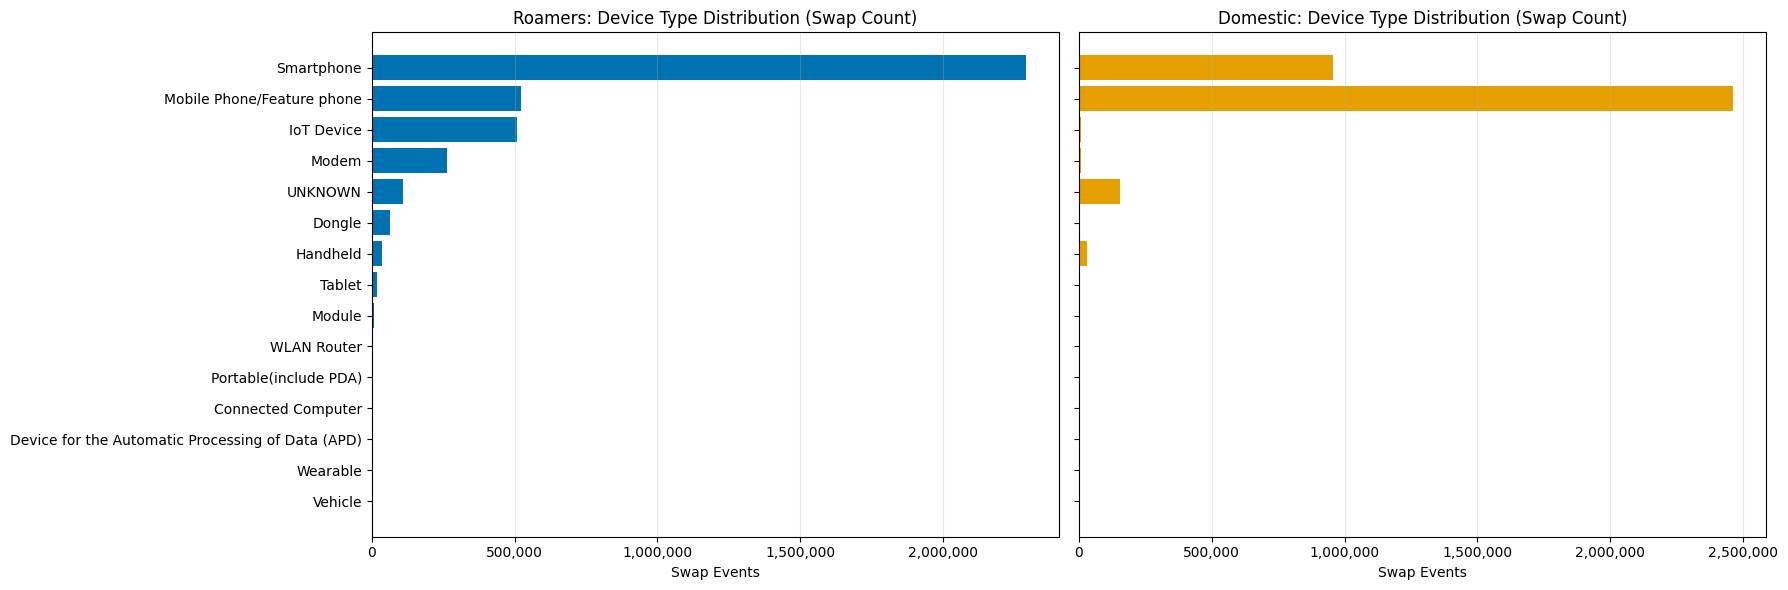

In [37]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

top_n = 15

dev_roamers = (
    df_roamers["device_type"]
    .fillna("UNKNOWN")
    .value_counts()
    .head(top_n)
    .sort_values()
)

dev_domestic = (
    df_domestic["device_type"]
    .fillna("UNKNOWN")
    .value_counts()
    .head(top_n)
    .sort_values()
)

fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=True)

axes[0].barh(dev_roamers.index, dev_roamers.values, color="#0072B2")
axes[0].set_title("Roamers: Device Type Distribution (Swap Count)")
axes[0].set_xlabel("Swap Events")
axes[0].grid(True, axis="x", alpha=0.3)
axes[0].invert_yaxis()

axes[1].barh(dev_domestic.index, dev_domestic.values, color="#E69F00")
axes[1].set_title("Domestic: Device Type Distribution (Swap Count)")
axes[1].set_xlabel("Swap Events")
axes[1].grid(True, axis="x", alpha=0.3)
axes[1].invert_yaxis()

# ---- Fix scientific notation ----
formatter = FuncFormatter(lambda x, _: f"{int(x):,}")
axes[0].xaxis.set_major_formatter(formatter)
axes[1].xaxis.set_major_formatter(formatter)

plt.tight_layout()
plt.show()

In [38]:
tab_dev_domestic = (
    df_domestic["device_type"]
    .fillna("UNKNOWN")
    .value_counts()
    .head(top_n)
    .reset_index()
)

tab_dev_domestic.columns = ["device_type", "swap_events"]
tab_dev_domestic.insert(0, "rank", range(1, len(tab_dev_domestic) + 1))

print("\nDOMESTIC – DEVICE TYPE DISTRIBUTION")
print("="*50)
tab_dev_domestic


DOMESTIC – DEVICE TYPE DISTRIBUTION


,rank,device_type,swap_events
0,1,Mobile Phone/Feature phone,2462077
1,2,Smartphone,957433
2,3,UNKNOWN,156568
3,4,Handheld,29401
4,5,Modem,9791
5,6,IoT Device,6917
6,7,Tablet,6326
7,8,Dongle,4796
8,9,Connected Computer,2033
9,10,Portable(include PDA),1662


In [39]:
tab_dev_roamers = (
    df_roamers["device_type"]
    .fillna("UNKNOWN")
    .value_counts()
    .head(top_n)
    .reset_index()
)

tab_dev_roamers.columns = ["device_type", "swap_events"]
tab_dev_roamers.insert(0, "rank", range(1, len(tab_dev_roamers) + 1))

print("\nROAMERS – DEVICE TYPE DISTRIBUTION")
print("="*50)
tab_dev_roamers


ROAMERS – DEVICE TYPE DISTRIBUTION


,rank,device_type,swap_events
0,1,Smartphone,2291102
1,2,Mobile Phone/Feature phone,522814
2,3,IoT Device,508577
3,4,Modem,262600
4,5,UNKNOWN,110968
5,6,Dongle,62259
6,7,Handheld,37675
7,8,Tablet,18031
8,9,Module,8959
9,10,WLAN Router,2810


#### We Clear Memory and Previous Data Frames

In [ ]:
import os
os._exit(0)

# SIM CHURN ANALYSIS

In [1]:
import pandas as pd

df_10_25 = pd.read_pickle("/Users/wmuheki/Documents/Projects/Analytics/KYC/clean_dumps/df_10_25.pkl")
df_11_25 = pd.read_pickle("/Users/wmuheki/Documents/Projects/Analytics/KYC/clean_dumps/df_11_25.pkl")
df_12_25 = pd.read_pickle("/Users/wmuheki/Documents/Projects/Analytics/KYC/clean_dumps/df_12_25.pkl")
df_01_26 = pd.read_pickle("/Users/wmuheki/Documents/Projects/Analytics/KYC/clean_dumps/df_01_26.pkl")

#### 1) Build a single longitudinal table (Oct 2025 –Jan 2026)

In [2]:
import pandas as pd
import numpy as np
import calendar

# ---- configure your month frames here ----
MONTH_DFS = {
    "10_25": df_10_25,
    "11_25": df_11_25,
    "12_25": df_12_25,
    "1_26": df_01_26,
}

DETAIL_COLS = ["first_name", "surname", "id_type", "prefix", "MNO"]


def month_end_from_mm_yy(mm_yy: str) -> pd.Timestamp:
    mm, yy = mm_yy.split("_")
    month = int(mm)
    year = 2000 + int(yy)
    last_day = calendar.monthrange(year, month)[1]
    return pd.Timestamp(year=year, month=month, day=last_day)


def prep_month(df: pd.DataFrame, mm_yy: str) -> pd.DataFrame:
    out = df.copy()

    out["period"] = month_end_from_mm_yy(mm_yy)

    # normalize keys as strings (important: keeps leading zeros)
    out["msisdn"] = out["msisdn"].astype(str).str.strip()
    out["id_number"] = out["id_number"].astype(str).str.strip()

    # clean id_type / other cols
    if "id_type" in out.columns:
        out["id_type"] = out["id_type"].astype(str).str.strip()

    for c in ["first_name", "surname", "prefix", "MNO"]:
        if c in out.columns:
            out[c] = out[c].astype(str).str.strip()

    # drop exact dupes within the same month (common in dumps)
    out = out.drop_duplicates(subset=["period", "msisdn", "id_number"])

    return out


allm = pd.concat([prep_month(df, k) for k, df in MONTH_DFS.items()], ignore_index=True)
allm = allm.sort_values(["msisdn", "period"]).reset_index(drop=True)

allm.head()

,msisdn,first_name,surname,id_type,id_number,prefix,MNO,period
0,0200100100,AIRTEL UGANDA LIMITED MARKETING SIM,NAN,COMPANY_ID,172591,0200,AIRTEL,2025-10-31
1,0200100100,AIRTEL UGANDA LIMITED MARKETING SIM,NAN,COMPANY_ID,172591,0200,AIRTEL,2025-11-30
2,0200100100,AIRTEL UGANDA LIMITED MARKETING SIM,NAN,COMPANY_ID,172591,0200,AIRTEL,2025-12-31
3,0200100100,AIRTEL UGANDA LIMITED MARKETING SIM,NAN,COMPANY_ID,172591,0200,AIRTEL,2026-01-31
4,0200900000,NAMAYINGO SCHOOL OF NURSING AND MIDWIFERY LTD,NAN,COMPANY_ID,80020003502069,0200,AIRTEL,2025-10-31


In [3]:
target_mnos = ["AIRTEL"]

airtel_churn = allm[
    allm["MNO"].isin(target_mnos)
].copy()

### Summary

In [4]:
import pandas as pd
import numpy as np

# ---------- INPUT ----------
df0 = airtel_churn.copy()
df0.columns = [c.lower() for c in df0.columns]

REQUIRED = {"msisdn", "id_number", "period"}
missing = sorted(list(REQUIRED - set(df0.columns)))
if missing:
    raise ValueError(f"Missing required columns: {missing}")

# keep only what you'll actually use (add/remove as needed)
DEFAULT_DETAIL = ["id_type", "first_name", "surname", "prefix", "imei", "tac", "district", "calling_location"]
DETAIL_COLS = [c for c in DEFAULT_DETAIL if c in df0.columns]

KEEP_COLS = ["msisdn", "id_number", "period"] + DETAIL_COLS
df0 = df0[KEEP_COLS].copy()

In [5]:
# normalize keys (keep leading zeros)
df0["msisdn"] = df0["msisdn"].astype(str).str.strip()
df0["id_number"] = df0["id_number"].astype(str).str.strip()
df0["period"] = pd.to_datetime(df0["period"], errors="coerce")

# month-end normalized timestamp
month = (df0["period"].dt.to_period("M").dt.to_timestamp() + pd.offsets.MonthEnd(0)).dt.normalize()
df0 = df0.assign(month=month).loc[month.notna()].copy()

# deduplicate within month snapshot (keep last per msisdn-month)
df1 = (
    df0.sort_values(["msisdn", "month", "period"])
       .drop_duplicates(["msisdn", "month"], keep="last")
       .reset_index(drop=True)
)

In [6]:
df = df1.sort_values(["msisdn", "month"]).reset_index(drop=True)

# shifts
df["prev_month"] = df.groupby("msisdn")["month"].shift(1)
df["prev_id_number"] = df.groupby("msisdn")["id_number"].shift(1)

for c in DETAIL_COLS:
    df[f"prev_{c}"] = df.groupby("msisdn")[c].shift(1)

# keep adjacent months only (cheap integer month index)
cur_mi  = df["month"].dt.to_period("M").astype(int)
prev_mi = df["prev_month"].dt.to_period("M").astype(int)
df["months_gap"] = (cur_mi - prev_mi).where(df["prev_month"].notna(), np.nan)

adj = df.loc[df["months_gap"].eq(1)].copy()

# ID change events
id_change = adj.loc[
    adj["prev_id_number"].notna() & (adj["id_number"] != adj["prev_id_number"])
].copy()

id_change["event_type"] = "ID_CHANGE"

# attribute change flags (only if detail exists)
for c in DETAIL_COLS:
    id_change[f"{c}_changed"] = (
        id_change[c].astype(str) != id_change[f"prev_{c}"].astype(str)
    )

In [7]:
months = np.sort(df1["month"].unique())

# base sizes per month
base = df1.groupby("month", as_index=False)["msisdn"].nunique().rename(columns={"msisdn": "base_msisdn"})

# ID_CHANGE counts per month (unique msisdn)
idc = id_change.groupby("month", as_index=False)["msisdn"].nunique().rename(columns={"msisdn": "id_change_msisdn"})

# Build prev/cur pairs
pairs = pd.DataFrame({"month": months[1:]})
pairs["prev_month"] = months[:-1]

pairs = pairs.merge(base.rename(columns={"month":"prev_month", "base_msisdn":"prev_base_msisdn"}), on="prev_month", how="left")
pairs = pairs.merge(base.rename(columns={"month":"month", "base_msisdn":"cur_base_msisdn"}), on="month", how="left")
pairs = pairs.merge(idc, on="month", how="left").fillna({"id_change_msisdn": 0})

# Attrition: msisdn in prev not in cur (anti-join)
prev_keys = df1[["month","msisdn"]].rename(columns={"month":"prev_month"})
cur_keys  = df1[["month","msisdn"]].copy()

attr_join = prev_keys.merge(
    cur_keys, left_on=["prev_month","msisdn"], right_on=["month","msisdn"],
    how="left", indicator=True
)
# NOTE: this join matches same month; we need prev vs cur month.
# So build per-pair by joining with pairs mapping:
attr = prev_keys.merge(pairs[["prev_month","month"]], on="prev_month", how="inner")  # adds cur month per prev
attr = attr.merge(cur_keys.rename(columns={"month":"month"}), on=["month","msisdn"], how="left", indicator=True)
attrition_events = attr.loc[attr["_merge"].eq("left_only"), ["month","msisdn"]].copy()
attrition_events["event_type"] = "ATTRITION"

# New: msisdn in cur not in prev (anti-join)
new = cur_keys.merge(pairs[["prev_month","month"]], on="month", how="inner")          # adds prev month per cur
new = new.merge(prev_keys, on=["prev_month","msisdn"], how="left", indicator=True)
new_events = new.loc[new["_merge"].eq("left_only"), ["month","msisdn"]].copy()
new_events["event_type"] = "NEW"

# counts
attr_counts = attrition_events.groupby("month", as_index=False)["msisdn"].size().rename(columns={"size":"attrition_msisdn"})
new_counts  = new_events.groupby("month", as_index=False)["msisdn"].size().rename(columns={"size":"new_msisdn"})

monthly_kpis = (
    pairs.merge(attr_counts, on="month", how="left")
         .merge(new_counts,  on="month", how="left")
         .fillna({"attrition_msisdn": 0, "new_msisdn": 0})
)

monthly_kpis["net_add_msisdn"] = monthly_kpis["cur_base_msisdn"] - monthly_kpis["prev_base_msisdn"]

# rates vs prev base
pb = monthly_kpis["prev_base_msisdn"].replace({0: np.nan})
monthly_kpis["id_change_rate_vs_prev_base"] = monthly_kpis["id_change_msisdn"] / pb
monthly_kpis["attrition_rate_vs_prev_base"] = monthly_kpis["attrition_msisdn"] / pb
monthly_kpis["new_rate_vs_prev_base"]       = monthly_kpis["new_msisdn"] / pb
monthly_kpis["total_churn_rate_vs_prev_base"] = (monthly_kpis["id_change_msisdn"] + monthly_kpis["attrition_msisdn"]) / pb

monthly_kpis = monthly_kpis.sort_values("month").reset_index(drop=True)

In [8]:
# lightweight lookup table: last record per msisdn-month already in df1
lookup = df1[["month","msisdn","id_number"] + DETAIL_COLS].copy()

# Attrition: attach previous month's last known record
if not attrition_events.empty:
    attrition_events["prev_month"] = (attrition_events["month"] - pd.offsets.MonthEnd(1)).dt.normalize()
    attrition_events = attrition_events.merge(
        lookup.rename(columns={"month":"prev_month", "id_number":"prev_id_number"}),
        on=["prev_month","msisdn"],
        how="left"
    )

# New: attach current month's record
if not new_events.empty:
    new_events = new_events.merge(
        lookup,
        on=["month","msisdn"],
        how="left"
    )

In [9]:
# A) Repeat churn MSISDNs (cycling)
repeat_churn = (
    id_change.groupby("msisdn").size().rename("n_id_changes")
             .sort_values(ascending=False).reset_index()
)
repeat_2  = int((repeat_churn["n_id_changes"] >= 2).sum())
repeat_5  = int((repeat_churn["n_id_changes"] >= 5).sum())
repeat_10 = int((repeat_churn["n_id_changes"] >= 10).sum())

# B) Rapid flips (adjacent-month by design)
id_change["days_between"] = (id_change["month"] - id_change["prev_month"]).dt.days
rapid_31 = int((id_change["days_between"] <= 31).sum())

# C) Attribute shift rates at churn time
attr_change_rates = []
for c in DETAIL_COLS:
    chg = f"{c}_changed"
    if chg in id_change.columns and len(id_change):
        attr_change_rates.append({
            "field": c,
            "changed_events": int(id_change[chg].sum()),
            "total_events": int(len(id_change)),
            "change_rate": float(id_change[chg].mean())
        })
attr_change_rates = pd.DataFrame(attr_change_rates).sort_values("change_rate", ascending=False)

# D) Top gainers / losers (keep minimal cols)
id_gain = (
    id_change.groupby("id_number")["msisdn"].nunique()
             .rename("msisdn_gained").sort_values(ascending=False).reset_index()
)
id_loss = (
    id_change.groupby("prev_id_number")["msisdn"].nunique()
             .rename("msisdn_lost").sort_values(ascending=False).reset_index()
)

In [10]:
def mode_clean(s: pd.Series):
    s = s.dropna().astype(str).str.strip()
    s = s.replace({"": np.nan}).dropna()
    if s.empty:
        return np.nan
    return s.value_counts().index[0]

# attach names for top gainers only
if {"first_name","surname"}.issubset(id_change.columns):
    top_ids = id_gain["id_number"].head(200)  # adjust
    name_src = id_change.loc[id_change["id_number"].isin(top_ids), ["id_number","first_name","surname"]].copy()

    names = (
        name_src.groupby("id_number", as_index=False)
                .agg(first_name=("first_name", mode_clean),
                     surname=("surname", mode_clean))
    )
    id_gain = id_gain.merge(names, on="id_number", how="left")

# attach prev names for top losers only
if {"prev_first_name","prev_surname","prev_id_number"}.issubset(id_change.columns):
    top_prev = id_loss["prev_id_number"].head(200)
    prev_src = id_change.loc[id_change["prev_id_number"].isin(top_prev), ["prev_id_number","prev_first_name","prev_surname"]].copy()

    prev_names = (
        prev_src.groupby("prev_id_number", as_index=False)
                .agg(prev_first_name=("prev_first_name", mode_clean),
                     prev_surname=("prev_surname", mode_clean))
    )
    id_loss = id_loss.merge(prev_names, on="prev_id_number", how="left")

In [11]:
corp_gain_top = None
if "id_type" in id_change.columns:
    corp = id_change[id_change["id_type"].astype(str).str.contains("COMPANY", na=False)]
    corp_gain_top = (
        corp.groupby("id_number")["msisdn"].nunique()
            .rename("msisdn_gained").sort_values(ascending=False).head(20).reset_index()
    )
    if {"first_name","surname"}.issubset(corp.columns):
        corp_names = (
            corp.groupby("id_number", as_index=False)
                .agg(first_name=("first_name", mode_clean),
                     surname=("surname", mode_clean))
        )
        corp_gain_top = corp_gain_top.merge(corp_names, on="id_number", how="left")

prefix_churn = None
if "prefix" in id_change.columns:
    prefix_churn = (
        id_change["prefix"].value_counts(dropna=False).head(20)
                 .rename("id_change_events").reset_index()
                 .rename(columns={"index":"prefix"})
    )

In [12]:
print("=" * 70)
print("AIRTEL MONTHLY SNAPSHOT – CHURN / FRAUD ANALYTICS SUMMARY")
print("=" * 70)

total_records = len(df1)
unique_msisdn = df1["msisdn"].nunique()
unique_ids = df1["id_number"].nunique()
months_covered = df1["month"].nunique()

print(f"Total Snapshot Records = {total_records:,}")
print(f"Unique MSISDNs (any month) = {unique_msisdn:,}")
print(f"Unique ID Numbers (any month) = {unique_ids:,}")
print(f"Months Covered = {months_covered:,}")

print("\n" + "-" * 70)
print("MONTHLY BASE + CHURN KPIs (last 6 months)")
show = monthly_kpis.copy()
for c in ["id_change_rate_vs_prev_base", "attrition_rate_vs_prev_base", "new_rate_vs_prev_base", "total_churn_rate_vs_prev_base"]:
    show[c] = (show[c] * 100).round(2)

cols = [
    "month",
    "prev_base_msisdn", "cur_base_msisdn",
    "id_change_msisdn", "attrition_msisdn", "new_msisdn", "net_add_msisdn",
    "id_change_rate_vs_prev_base", "attrition_rate_vs_prev_base", "new_rate_vs_prev_base", "total_churn_rate_vs_prev_base"
]
print(show[cols].tail(6).to_string(index=False))

print("\n" + "-" * 70)
print("OWNERSHIP-CHANGE CHURN (ID_CHANGE) – CORE STATS")
print(f"Total ID_CHANGE events = {len(id_change):,}")
print(f"Unique MSISDNs with ID_CHANGE = {id_change['msisdn'].nunique():,}")
print(f"Unique previous IDs = {id_change['prev_id_number'].nunique():,}")
print(f"Unique new IDs = {id_change['id_number'].nunique():,}")
print(f"Adjacent-month flips (<=31 days) = {rapid_31:,}")

print("\n" + "-" * 70)
print("REPEAT CHURN (CYCLING) – MSISDNs")
print(f"MSISDNs with ≥2 ID changes = {repeat_2:,}")
print(f"MSISDNs with ≥5 ID changes = {repeat_5:,}")
print(f"MSISDNs with ≥10 ID changes (High Risk) = {repeat_10:,}")

print("\n" + "-" * 70)
print("TOP ID GAINERS – Top 20")
gain_cols = [c for c in ["id_number", "first_name", "surname", "msisdn_gained"] if c in id_gain.columns]
print(id_gain[gain_cols].head(20).to_string(index=False))

print("\n" + "-" * 70)
print("TOP ID LOSERS – Top 20")
loss_cols = [c for c in ["prev_id_number", "prev_first_name", "prev_surname", "msisdn_lost"] if c in id_loss.columns]
print(id_loss[loss_cols].head(20).to_string(index=False))

print("\n" + "-" * 70)
print("ATTRITION + NEW ACTIVATION – last 6 months (counts)")
print(monthly_kpis[["month", "attrition_msisdn", "new_msisdn"]].tail(6).to_string(index=False))

if not attr_change_rates.empty:
    print("\n" + "-" * 70)
    print("ATTRIBUTE SHIFT AT CHURN TIME – Top fields")
    out = attr_change_rates.copy()
    out["change_rate"] = (out["change_rate"] * 100).round(2)
    print(out.head(20).to_string(index=False))

if corp_gain_top is not None and not corp_gain_top.empty:
    print("\n" + "-" * 70)
    print("CORPORATE INFLOW (IDs containing 'COMPANY') – Top 20")
    corp_cols = [c for c in ["id_number", "first_name", "surname", "msisdn_gained"] if c in corp_gain_top.columns]
    print(corp_gain_top[corp_cols].to_string(index=False))

if prefix_churn is not None and not prefix_churn.empty:
    print("\n" + "-" * 70)
    print("PREFIX DISTRIBUTION IN ID_CHANGE (Top 20)")
    print(prefix_churn.to_string(index=False))

print("=" * 70)

AIRTEL MONTHLY SNAPSHOT – CHURN / FRAUD ANALYTICS SUMMARY
Total Snapshot Records = 95,683,847
Unique MSISDNs (any month) = 25,124,930
Unique ID Numbers (any month) = 11,131,390
Months Covered = 4

----------------------------------------------------------------------
MONTHLY BASE + CHURN KPIs (last 6 months)
     month  prev_base_msisdn  cur_base_msisdn  id_change_msisdn  attrition_msisdn  new_msisdn  net_add_msisdn  id_change_rate_vs_prev_base  attrition_rate_vs_prev_base  new_rate_vs_prev_base  total_churn_rate_vs_prev_base
2025-11-30          23963295         24183547            282999            526250      746502          220252                         1.18                         2.20                   3.12                           3.38
2025-12-31          24183547         23571285            713337            958703      346441         -612262                         2.95                         3.96                   1.43                           6.91
2026-01-31          2357

### Graphs

In [16]:
k = monthly_kpis.copy()

# Ensure datetime
k["month"] = pd.to_datetime(k["month"], errors="coerce")
k = k[k["month"].notna()].sort_values("month").reset_index(drop=True)

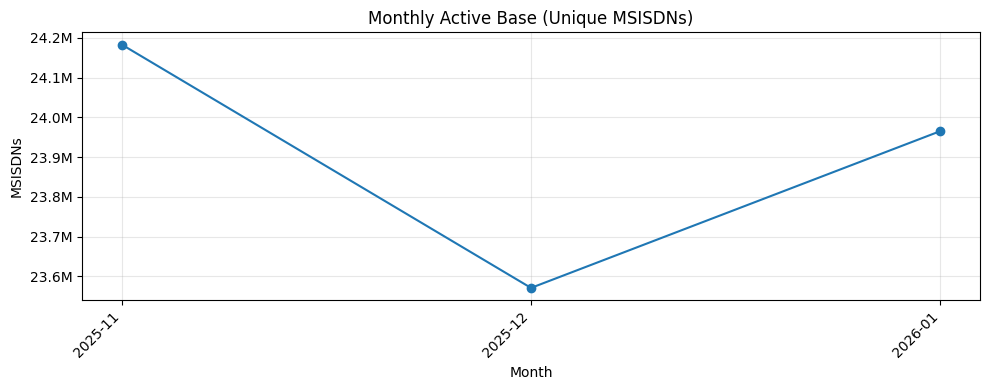


TABLE 1: Monthly Active Base
  month  cur_base_msisdn_raw cur_base_msisdn_fmt
2025-11             24183547               24.2M
2025-12             23571285               23.6M
2026-01             23965720               24.0M


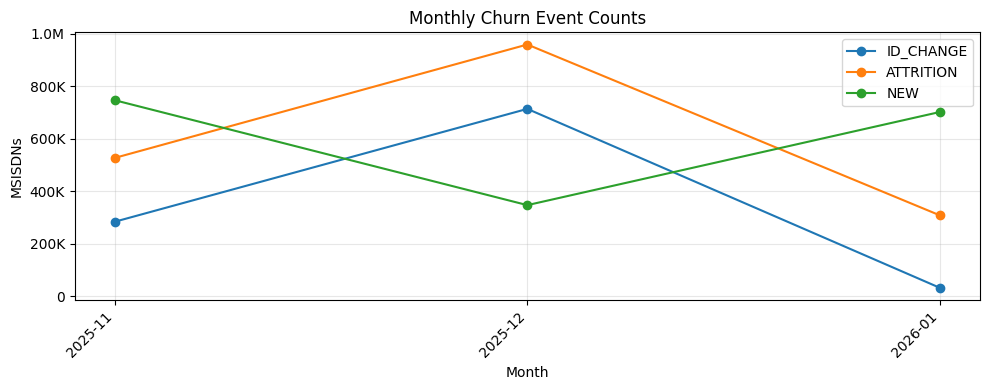


TABLE 2: Monthly Churn Event Counts
  month  id_change_msisdn  attrition_msisdn  new_msisdn
2025-11            282999            526250      746502
2025-12            713337            958703      346441
2026-01             30940            307196      701631


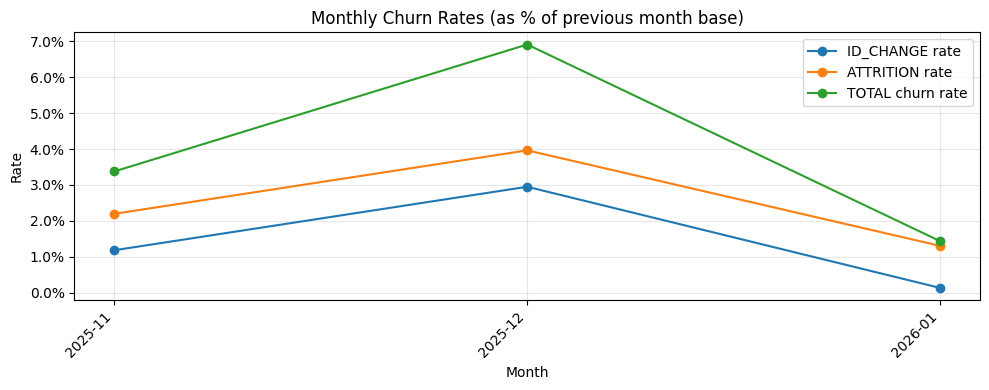


TABLE 3: Monthly Churn Rates
  month  id_change_rate_vs_prev_base  attrition_rate_vs_prev_base  total_churn_rate_vs_prev_base id_change_rate_vs_prev_base_fmt attrition_rate_vs_prev_base_fmt total_churn_rate_vs_prev_base_fmt
2025-11                     0.011810                     0.021961                       0.033770                            1.2%                            2.2%                              3.4%
2025-12                     0.029497                     0.039643                       0.069140                            2.9%                            4.0%                              6.9%
2026-01                     0.001313                     0.013033                       0.014345                            0.1%                            1.3%                              1.4%


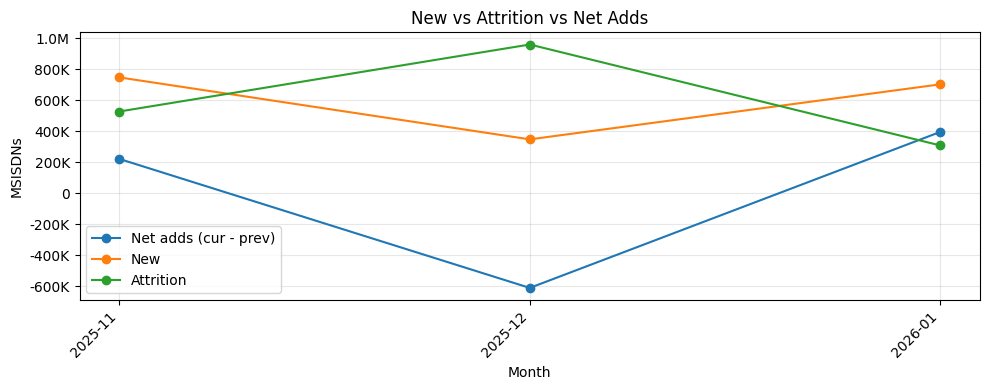


TABLE 4: New vs Attrition vs Net Adds
  month  net_add_msisdn  new_msisdn  attrition_msisdn
2025-11          220252      746502            526250
2025-12         -612262      346441            958703
2026-01          394435      701631            307196


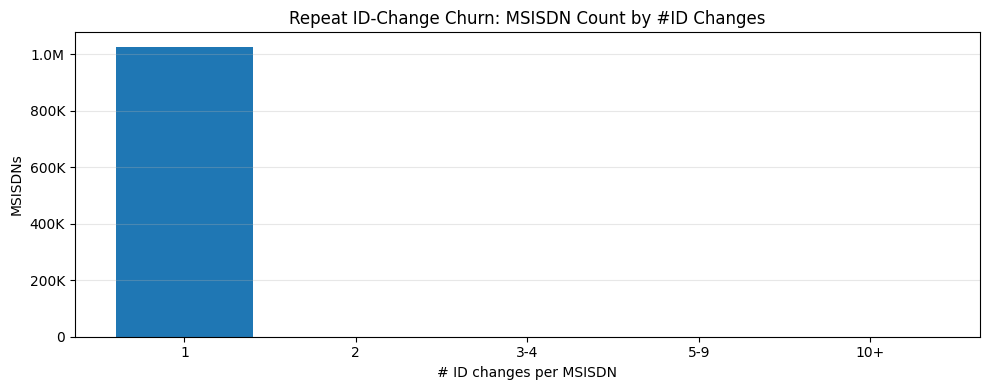


TABLE 5: Repeat ID-Change Distribution
n_id_changes_bucket  msisdn_count
                  1       1026996
                  2           140
                3-4             0
                5-9             0
                10+             0


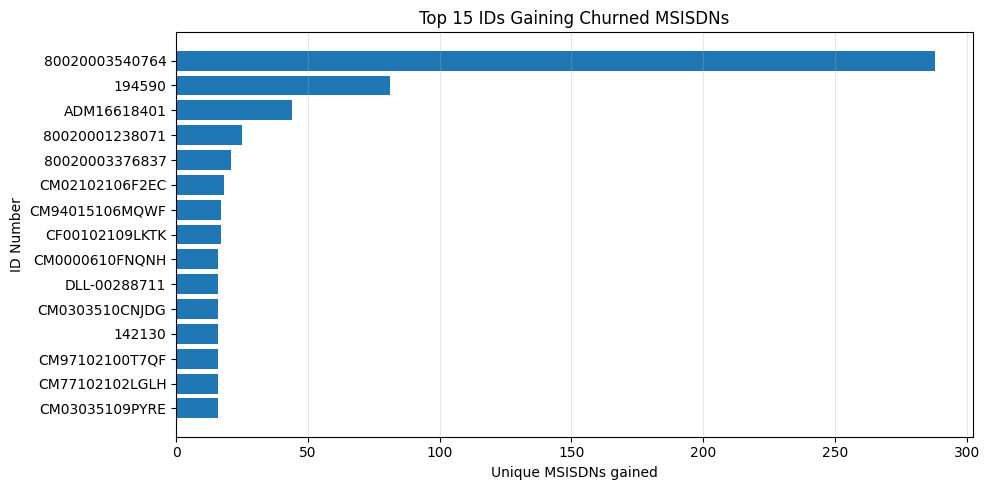


TABLE 6A: Top 15 IDs Gaining MSISDNs
 rank      id_number  msisdn_gained
    1 80020003540764            288
    2         194590             81
    3    ADM16618401             44
    4 80020001238071             25
    5 80020003376837             21
    6 CM02102106F2EC             18
    7 CM94015106MQWF             17
    8 CF00102109LKTK             17
    9 CM0000610FNQNH             16
   10   DLL-00288711             16
   11 CM0303510CNJDG             16
   12         142130             16
   13 CM97102100T7QF             16
   14 CM77102102LGLH             16
   15 CM03035109PYRE             16


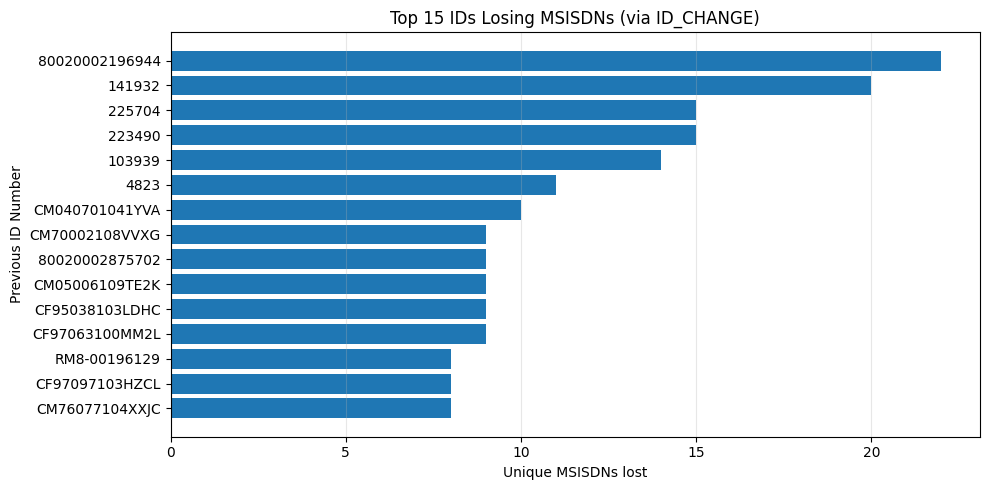


TABLE 6B: Top 15 IDs Losing MSISDNs
 rank prev_id_number  msisdn_lost
    1 80020002196944           22
    2         141932           20
    3         225704           15
    4         223490           15
    5         103939           14
    6           4823           11
    7 CM040701041YVA           10
    8 CM70002108VVXG            9
    9 80020002875702            9
   10 CM05006109TE2K            9
   11 CF95038103LDHC            9
   12 CF97063100MM2L            9
   13   RM8-00196129            8
   14 CF97097103HZCL            8
   15 CM76077104XXJC            8


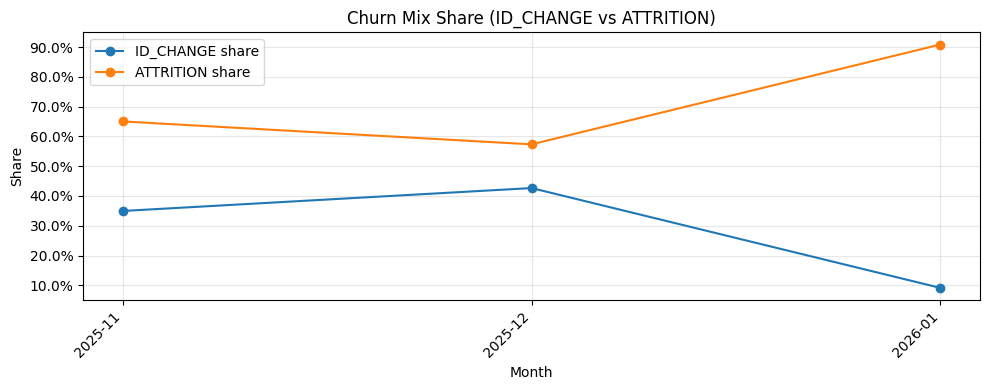


TABLE 7: Churn Mix Share
  month  total_churn_events  id_change_share  attrition_share id_change_share_fmt attrition_share_fmt
2025-11              809249         0.349706         0.650294               35.0%               65.0%
2025-12             1672040         0.426627         0.573373               42.7%               57.3%
2026-01              338136         0.091502         0.908498                9.2%               90.8%


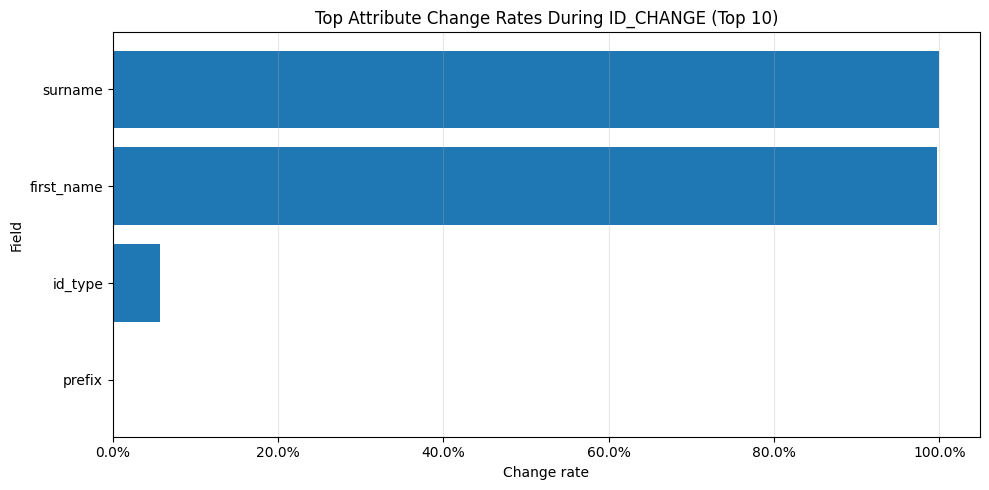


TABLE 8: Attribute Change Rates (Top 10)
     field  change_rate change_rate_fmt
   surname     0.999192           99.9%
first_name     0.997331           99.7%
   id_type     0.056525            5.7%
    prefix     0.000000            0.0%


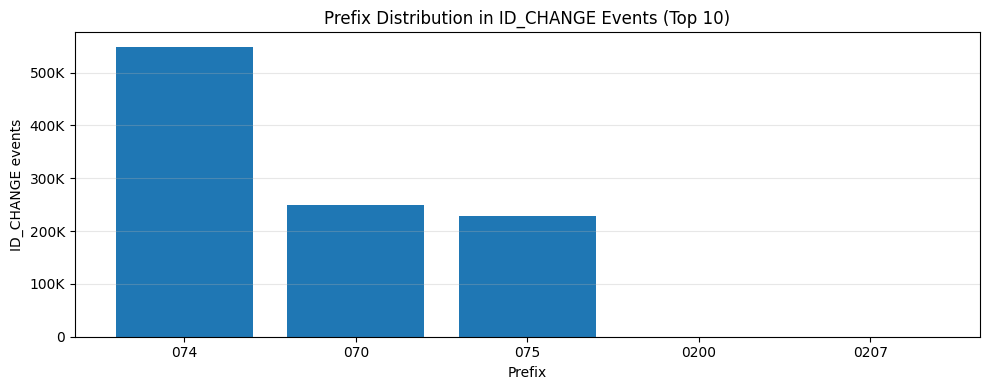


TABLE 9: Prefix Distribution in ID_CHANGE (Top 10)
 rank prefix  id_change_events
    1    074            548804
    2    070            250118
    3    075            228012
    4   0200               273
    5   0207                69


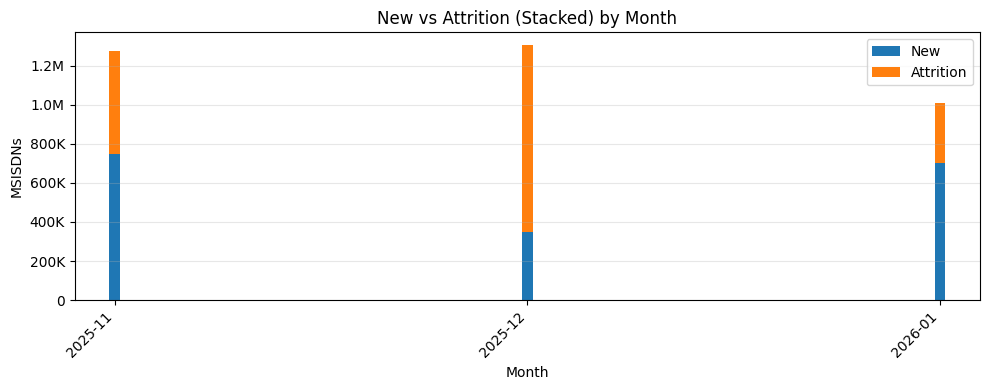


TABLE 10: New vs Attrition (Stacked) by Month
  month  new_msisdn  attrition_msisdn   total
2025-11      746502            526250 1272752
2025-12      346441            958703 1305144
2026-01      701631            307196 1008827


In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter

# ============================================================
# FULL WORKING PLOTTING + TABLE SCRIPT
# Assumes you already ran the churn prep script and have:
#   - monthly_kpis  (required)
# Optional (if present, will be used):
#   - repeat_churn, id_gain, id_loss, attr_change_rates, prefix_churn
# ============================================================

# -----------------------------
# Helpers
# -----------------------------
def fmt_k(x, pos=None):
    if pd.isna(x):
        return ""
    x = float(x)
    if abs(x) >= 1e6:
        return f"{x/1e6:.1f}M"
    if abs(x) >= 1e3:
        return f"{x/1e3:.0f}K"
    return f"{x:.0f}"

def fmt_pct(x, pos=None):
    if pd.isna(x):
        return ""
    return f"{x*100:.1f}%"

def format_month_axis(ax, months, rotate=45):
    months = pd.to_datetime(months, errors="coerce")
    months = months[~pd.isna(months)]
    months = np.unique(months)
    months = np.sort(months)

    if len(months) == 0:
        return

    ax.set_xticks(months)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    plt.setp(ax.get_xticklabels(), rotation=rotate, ha="right")
    ax.set_xlim(months.min() - pd.Timedelta(days=3),
                months.max() + pd.Timedelta(days=3))

def finalize(ax, title, xlabel="Month", ylabel=None, yfmt=None, legend=False, grid_axis="both"):
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    if ylabel is not None:
        ax.set_ylabel(ylabel)

    if yfmt is not None:
        ax.yaxis.set_major_formatter(FuncFormatter(yfmt))

    if legend:
        ax.legend()

    if grid_axis == "y":
        ax.grid(True, axis="y", alpha=0.3)
    elif grid_axis == "x":
        ax.grid(True, axis="x", alpha=0.3)
    else:
        ax.grid(True, alpha=0.3)

    plt.tight_layout()

def require_cols(df, cols, context=""):
    missing = [c for c in cols if c not in df.columns]
    if missing:
        raise KeyError(
            f"Missing columns {missing} {('in ' + context) if context else ''}. "
            f"Available: {list(df.columns)}"
        )

def show_table(title, df_show):
    print("\n" + "=" * 80)
    print(title)
    print("=" * 80)
    if df_show is None or df_show.empty:
        print("(empty)")
    else:
        print(df_show.to_string(index=False))

# -----------------------------
# Resolve monthly_kpis -> k
# -----------------------------
if "monthly_kpis" not in globals():
    raise NameError("monthly_kpis is not defined. Run your churn KPI build script first.")

# Compatibility: disappeared_msisdn -> attrition_msisdn
if "attrition_msisdn" not in monthly_kpis.columns and "disappeared_msisdn" in monthly_kpis.columns:
    monthly_kpis = monthly_kpis.rename(columns={"disappeared_msisdn": "attrition_msisdn"})

k = monthly_kpis.copy()
require_cols(k, ["month"], "monthly_kpis")

k["month"] = pd.to_datetime(k["month"], errors="coerce")
k = k[k["month"].notna()].sort_values("month").reset_index(drop=True)

if k.empty:
    raise ValueError("monthly_kpis is empty after month parsing. Check upstream churn KPI build.")

months = k["month"].values

# ============================================================
# 1) Monthly Active Base (Counts) + Table
# ============================================================
require_cols(k, ["month", "cur_base_msisdn"], "monthly_kpis")

plt.figure(figsize=(10, 4))
ax = plt.gca()
ax.plot(k["month"], k["cur_base_msisdn"], marker="o")
format_month_axis(ax, months)
finalize(ax, "Monthly Active Base (Unique MSISDNs)", ylabel="MSISDNs", yfmt=fmt_k)
plt.show()

t1 = k[["month", "cur_base_msisdn"]].copy()
t1["month"] = t1["month"].dt.strftime("%Y-%m")
t1["cur_base_msisdn_fmt"] = t1["cur_base_msisdn"].map(fmt_k)
show_table("TABLE 1: Monthly Active Base", t1.rename(columns={"cur_base_msisdn": "cur_base_msisdn_raw"}))

# ============================================================
# 2) Monthly Churn Event Counts + Table
# ============================================================
require_cols(k, ["month", "id_change_msisdn", "attrition_msisdn", "new_msisdn"], "monthly_kpis")

plt.figure(figsize=(10, 4))
ax = plt.gca()
ax.plot(k["month"], k["id_change_msisdn"], marker="o", label="ID_CHANGE")
ax.plot(k["month"], k["attrition_msisdn"], marker="o", label="ATTRITION")
ax.plot(k["month"], k["new_msisdn"], marker="o", label="NEW")
format_month_axis(ax, months)
finalize(ax, "Monthly Churn Event Counts", ylabel="MSISDNs", yfmt=fmt_k, legend=True)
plt.show()

t2 = k[["month", "id_change_msisdn", "attrition_msisdn", "new_msisdn"]].copy()
t2["month"] = t2["month"].dt.strftime("%Y-%m")
show_table("TABLE 2: Monthly Churn Event Counts", t2)

# ============================================================
# 3) Monthly Churn Rates + Table
# ============================================================
require_cols(
    k,
    ["month", "id_change_rate_vs_prev_base", "attrition_rate_vs_prev_base", "total_churn_rate_vs_prev_base"],
    "monthly_kpis"
)

plt.figure(figsize=(10, 4))
ax = plt.gca()
ax.plot(k["month"], k["id_change_rate_vs_prev_base"], marker="o", label="ID_CHANGE rate")
ax.plot(k["month"], k["attrition_rate_vs_prev_base"], marker="o", label="ATTRITION rate")
ax.plot(k["month"], k["total_churn_rate_vs_prev_base"], marker="o", label="TOTAL churn rate")
format_month_axis(ax, months)
finalize(ax, "Monthly Churn Rates (as % of previous month base)", ylabel="Rate", yfmt=fmt_pct, legend=True)
plt.show()

t3 = k[[
    "month",
    "id_change_rate_vs_prev_base",
    "attrition_rate_vs_prev_base",
    "total_churn_rate_vs_prev_base"
]].copy()
t3["month"] = t3["month"].dt.strftime("%Y-%m")
for c in ["id_change_rate_vs_prev_base", "attrition_rate_vs_prev_base", "total_churn_rate_vs_prev_base"]:
    t3[c + "_fmt"] = t3[c].map(fmt_pct)
show_table("TABLE 3: Monthly Churn Rates", t3)

# ============================================================
# 4) New vs Attrition vs Net Adds + Table
# ============================================================
require_cols(k, ["month", "net_add_msisdn", "new_msisdn", "attrition_msisdn"], "monthly_kpis")

plt.figure(figsize=(10, 4))
ax = plt.gca()
ax.plot(k["month"], k["net_add_msisdn"], marker="o", label="Net adds (cur - prev)")
ax.plot(k["month"], k["new_msisdn"], marker="o", label="New")
ax.plot(k["month"], k["attrition_msisdn"], marker="o", label="Attrition")
format_month_axis(ax, months)
finalize(ax, "New vs Attrition vs Net Adds", ylabel="MSISDNs", yfmt=fmt_k, legend=True)
plt.show()

t4 = k[["month", "net_add_msisdn", "new_msisdn", "attrition_msisdn"]].copy()
t4["month"] = t4["month"].dt.strftime("%Y-%m")
show_table("TABLE 4: New vs Attrition vs Net Adds", t4)

# ============================================================
# 5) Repeat Churners Distribution + Table (optional)
# ============================================================
if "repeat_churn" in globals() and isinstance(repeat_churn, pd.DataFrame) and not repeat_churn.empty:
    rc = repeat_churn.copy()
    require_cols(rc, ["n_id_changes"], "repeat_churn")

    rc["n_id_changes"] = pd.to_numeric(rc["n_id_changes"], errors="coerce")
    rc = rc.dropna(subset=["n_id_changes"])

    rc["bucket"] = pd.cut(
        rc["n_id_changes"],
        bins=[0, 1, 2, 4, 9, np.inf],
        labels=["1", "2", "3-4", "5-9", "10+"],
        right=True,
        include_lowest=True,
    )
    dist = rc["bucket"].value_counts().sort_index()

    plt.figure(figsize=(10, 4))
    ax = plt.gca()
    ax.bar(dist.index.astype(str), dist.values)
    finalize(ax, "Repeat ID-Change Churn: MSISDN Count by #ID Changes",
             xlabel="# ID changes per MSISDN", ylabel="MSISDNs", yfmt=fmt_k, grid_axis="y")
    plt.show()

    t5 = dist.reset_index()
    t5.columns = ["n_id_changes_bucket", "msisdn_count"]
    show_table("TABLE 5: Repeat ID-Change Distribution", t5)
else:
    print("\n[INFO] repeat_churn not found (or empty). Skipping repeat churn plots/tables.")

# ============================================================
# 6) Concentration: Top Additions (id_gain) + Table (optional)
# ============================================================
topN = 15
if "id_gain" in globals() and isinstance(id_gain, pd.DataFrame) and not id_gain.empty:
    require_cols(id_gain, ["id_number", "msisdn_gained"], "id_gain")
    g = id_gain.head(topN).copy()
    g["msisdn_gained"] = pd.to_numeric(g["msisdn_gained"], errors="coerce")

    plt.figure(figsize=(10, 5))
    ax = plt.gca()
    ax.barh(g["id_number"].astype(str)[::-1], g["msisdn_gained"][::-1])
    ax.xaxis.set_major_formatter(FuncFormatter(fmt_k))
    finalize(ax, f"Top {topN} IDs Gaining Churned MSISDNs",
             xlabel="Unique MSISDNs gained", ylabel="ID Number", grid_axis="x")
    plt.show()

    t6a = g[["id_number", "msisdn_gained"]].copy()
    t6a.insert(0, "rank", range(1, len(t6a) + 1))
    show_table(f"TABLE 6A: Top {topN} IDs Gaining MSISDNs", t6a)
else:
    print("\n[INFO] id_gain not found (or empty). Skipping top gainers plot/table.")

# 6B) Concentration: Top Losses (id_loss) + Table (optional)
if "id_loss" in globals() and isinstance(id_loss, pd.DataFrame) and not id_loss.empty:
    require_cols(id_loss, ["prev_id_number", "msisdn_lost"], "id_loss")
    l = id_loss.head(topN).copy()
    l["msisdn_lost"] = pd.to_numeric(l["msisdn_lost"], errors="coerce")

    plt.figure(figsize=(10, 5))
    ax = plt.gca()
    ax.barh(l["prev_id_number"].astype(str)[::-1], l["msisdn_lost"][::-1])
    ax.xaxis.set_major_formatter(FuncFormatter(fmt_k))
    finalize(ax, f"Top {topN} IDs Losing MSISDNs (via ID_CHANGE)",
             xlabel="Unique MSISDNs lost", ylabel="Previous ID Number", grid_axis="x")
    plt.show()

    t6b = l[["prev_id_number", "msisdn_lost"]].copy()
    t6b.insert(0, "rank", range(1, len(t6b) + 1))
    show_table(f"TABLE 6B: Top {topN} IDs Losing MSISDNs", t6b)
else:
    print("\n[INFO] id_loss not found (or empty). Skipping top losers plot/table.")

# ============================================================
# 7) Churn Event Mix Share + Table
# ============================================================
require_cols(k, ["month", "id_change_msisdn", "attrition_msisdn"], "monthly_kpis")

mix = k[["month", "id_change_msisdn", "attrition_msisdn"]].copy()
mix["total_churn_events"] = mix["id_change_msisdn"] + mix["attrition_msisdn"]

mix["id_change_share"] = np.where(
    mix["total_churn_events"] > 0,
    mix["id_change_msisdn"] / mix["total_churn_events"],
    np.nan
)
mix["attrition_share"] = np.where(
    mix["total_churn_events"] > 0,
    mix["attrition_msisdn"] / mix["total_churn_events"],
    np.nan
)

plt.figure(figsize=(10, 4))
ax = plt.gca()
ax.plot(mix["month"], mix["id_change_share"], marker="o", label="ID_CHANGE share")
ax.plot(mix["month"], mix["attrition_share"], marker="o", label="ATTRITION share")
format_month_axis(ax, months)
finalize(ax, "Churn Mix Share (ID_CHANGE vs ATTRITION)", ylabel="Share", yfmt=fmt_pct, legend=True)
plt.show()

t7 = mix[["month", "total_churn_events", "id_change_share", "attrition_share"]].copy()
t7["month"] = t7["month"].dt.strftime("%Y-%m")
t7["id_change_share_fmt"] = t7["id_change_share"].map(fmt_pct)
t7["attrition_share_fmt"] = t7["attrition_share"].map(fmt_pct)
show_table("TABLE 7: Churn Mix Share", t7)

# ============================================================
# 8) Attribute Shift Rates + Table (optional)
# ============================================================
if "attr_change_rates" in globals() and isinstance(attr_change_rates, pd.DataFrame) and not attr_change_rates.empty:
    require_cols(attr_change_rates, ["field", "change_rate"], "attr_change_rates")

    a = attr_change_rates.copy()
    a["change_rate"] = pd.to_numeric(a["change_rate"], errors="coerce")
    a = a.dropna(subset=["change_rate"]).sort_values("change_rate", ascending=False).head(10)

    plt.figure(figsize=(10, 5))
    ax = plt.gca()
    ax.barh(a["field"][::-1], a["change_rate"][::-1])
    ax.xaxis.set_major_formatter(FuncFormatter(fmt_pct))
    finalize(ax, "Top Attribute Change Rates During ID_CHANGE (Top 10)",
             xlabel="Change rate", ylabel="Field", grid_axis="x")
    plt.show()

    t8 = a[["field", "change_rate"]].copy()
    t8["change_rate_fmt"] = t8["change_rate"].map(fmt_pct)
    show_table("TABLE 8: Attribute Change Rates (Top 10)", t8)
else:
    print("\n[INFO] attr_change_rates not found (or empty). Skipping attribute shift plots/tables.")

# ============================================================
# 9) Prefix Skew in ID_CHANGE + Table (optional)
# ============================================================
if "prefix_churn" in globals() and isinstance(prefix_churn, pd.DataFrame) and not prefix_churn.empty:
    if {"prefix", "id_change_events"}.issubset(prefix_churn.columns):
        p = prefix_churn.head(10).copy()
        p["id_change_events"] = pd.to_numeric(p["id_change_events"], errors="coerce")

        plt.figure(figsize=(10, 4))
        ax = plt.gca()
        ax.bar(p["prefix"].astype(str), p["id_change_events"])
        finalize(ax, "Prefix Distribution in ID_CHANGE Events (Top 10)",
                 xlabel="Prefix", ylabel="ID_CHANGE events", yfmt=fmt_k, grid_axis="y")
        plt.show()

        t9 = p[["prefix", "id_change_events"]].copy()
        t9.insert(0, "rank", range(1, len(t9) + 1))
        show_table("TABLE 9: Prefix Distribution in ID_CHANGE (Top 10)", t9)
    else:
        print("\n[INFO] prefix_churn missing required columns. Skipping prefix plots/tables.")
else:
    print("\n[INFO] prefix_churn not found (or empty). Skipping prefix plots/tables.")

# ============================================================
# 10) New vs Attrition (Stacked) + Table
# ============================================================
require_cols(k, ["month", "new_msisdn", "attrition_msisdn"], "monthly_kpis")

plt.figure(figsize=(10, 4))
ax = plt.gca()
ax.bar(k["month"], k["new_msisdn"], label="New")
ax.bar(k["month"], k["attrition_msisdn"], bottom=k["new_msisdn"], label="Attrition")
format_month_axis(ax, months)
finalize(ax, "New vs Attrition (Stacked) by Month", ylabel="MSISDNs", yfmt=fmt_k, legend=True, grid_axis="y")
plt.show()

t10 = k[["month", "new_msisdn", "attrition_msisdn"]].copy()
t10["month"] = t10["month"].dt.strftime("%Y-%m")
t10["total"] = t10["new_msisdn"] + t10["attrition_msisdn"]
show_table("TABLE 10: New vs Attrition (Stacked) by Month", t10)

#### We Clear Memory and Previous Data Frames

In [ ]:
import os
os._exit(0)